# 🇰🇷 ↔️ 🇺🇸 Korean-English Neural Machine Translation (NMT)

본 프로젝트는 고품질의 한국어-영어 병렬 코퍼스를 활용하여, 문맥을 이해하고 정교하게 번역하는 **Attention 기반 Seq2Seq 번역 모델**을 구축하는 것을 목표로 합니다.

## 📊 1. 데이터셋 정보 (Dataset Source)
본 프로젝트는 다음의 공개된 병렬 말뭉치를 기반으로 학습되었습니다.
- **Source**: [jungyeul/korean-parallel-corpora (v1.0)](https://github.com/jungyeul/korean-parallel-corpora/tree/master/korean-english-news-v1)
- **Content**: 한국어-영어 뉴스 데이터 (Parallel News Corpus)

---

## 🏗️ 2. 데이터 엔지니어링 전략 (Data Engineering)

딥러닝 모델의 성능은 데이터의 질에 비례합니다. 본 프로젝트는 "엄격한 선별(길이 toknen 40)과 넉넉한 수용(64)"이라는 이원화된 전략을 취합니다.

1. **엄격한 문장 선별 (`PRE_MAX_LEN: 40`)**:
   - 학습 효율과 번역의 명확성을 위해, 전처리(띄어쓰기 및 형태소 분석) 기준 **단어 수가 40개 이하인 고품질 문장 쌍**만을 필터링하여 학습 데이터로 채택합니다.
   - 너무 긴 문장은 학습 시간을 과도하게 늘리고 문맥의 집중도를 분산시키기 때문에, 과감하게 "짧고 확실한 데이터" 위주로 정제하였습니다.

2. **넉넉한 학습 차원 (`MAX_LEN: 64`)**:
   - 실제 모델에 입력될 때는 **64토큰** 으로 설정합니다. 
   - **이유**: 한국어는 BPE(서브워드) 토크나이징 시 조사나 어미가 분리되면서 원래 단어 수보다 토큰 수가 1.5배~1.8배 늘어납니다. 따라서 40단어 이하로 선별한 문장이더라도, **토큰화 후 정보 유실(Truncation)을 막기 위해 64라는 여유로운 마지노선** 을 설정하여 학습 품질을 보장했습니다.

---

## 🏭 3. 핵심 아키텍처 및 고도화 기술

- **Architecture**: **Bahdanau Attention** 기반의 **Encoder-Decoder (GRU)** 구조
- **Tokenizer**: 20,000 Vocab Size의 **BPE (Byte Pair Encoding)** 커스텀 토크나이저
- **Optimization Strategy**:
    - **🔥 Scheduled Teacher Forcing (0.8)**: 80% 확률로 정답을, 20% 확률로 자율 예측을 수행하여 "오바마-Obama"와 같은 단어 매칭(Attention Alignment) 능력을 극대화함.
    - Bean Search: Greedy 방식대신에 bean serach 상위 3개의 우수 후보 문장(평행 우주)을 동시에 살려두며 탐색을 진행

---
**💡 최종 진단**: 본 설계는 데이터의 물리적 한계를 데이터 엔지니어링으로 극복하고, 모델의 자립성을 키워 실전 번역력을 높이는 데 집중되어 있습니다.


In [16]:
# 각종 라이브러리 import

import re
import pandas as pd
from konlpy.tag import Mecab
import os
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace

import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.font_manager as fm


import random


## 하이퍼파라미터 및 환경 설정 (Model Configuration)

본 프로젝트의 모든 핵심 수치와 경로 설정은 `CFG` 객체를 통해 통합 관리됩니다. 이는 실험의 **재현성(Reproducibility)**을 보장하고, 하이퍼파라미터 튜닝을 효율적으로 수행하기 위한 **중앙 통제실** 역할을 합니다.

### ⚙️ 핵심 설정 가이드 (`CFG`)

1. **말뭉치 및 도구 경로 (Data & Path Settings)**:
   - **원본 및 정제 데이터**: 입력 데이터(`KO_RAW_PATH`, `EN_RAW_PATH`)와 정제 후 저장될 말뭉치(`KO_CORPUS_OUT`, `EN_CORPUS_OUT`)의 경로를 지정합니다.
   - **Mecab 사전**: 한국어 형태소 분석을 위한 사전 경로(`MECAB_DIC_PATH`)를 명시하여 맥(Mac Homebrew) 환경에서도 안정적으로 구동되도록 설정합니다.

2. **토크나이저 및 단어 사전 (Tokenizer & Vocab)**:
   - **`VOCAB_SIZE`: 20,000**: 너무 크면 학습이 희소해지고, 너무 작으면 모르는 단어(`[UNK]`)가 많아져 번역 품질이 떨어집니다. 20,000개는 일상적인 뉴스 및 대화 데이터를 충분히 포괄할 수 있는 **최적의 단어 크기**입니다.
   - **`SPECIAL_TOKENS`**: 문장의 시작(`<start>`), 끝(`<end>`), 길이 맞춤용 패딩(`[PAD]`), 미등록 단어(`[UNK]`) 등 인공 신경망이 문장 구조를 이해하기 위한 필수 약속을 정의합니다.

3. **데이터셋 및 학습 장치 (Dataset & Device)**:
   - **`MAX_LEN`: 64**: 한국어는 형태소나 BPE로 쪼개질 때 단어 수보다 토큰 수가 약 1.5~1.8배 늘어납니다. 64는 **40단어 이하 문장의 정보를 유실 없이(Truncation 방지) 안전하게 담아낼 수 있는 마지노선**입니다.
   - **`DEVICE`**: 사용 중인 하드웨어 환경에 맞춰 **GPU(CUDA)**, **Apple Silicon(MPS)**, 혹은 **CPU** 중 가장 빠른 연산 장치를 자동으로 선택하도록 지능형 로직을 적용합니다.

4. **모델 아키텍처 및 학습 전략 (Model Parameters)**:
   - **`EMB_DIM`: 256 / `HID_DIM`: 512**: 단어의 의미적 공간을 256차원으로, 문장의 압축된 생각을 512차원으로 표현하여 **번역의 깊이와 정교함**을 확보합니다.
   - **🔥 `TEACHER_FORCING`: 0.8**: 모델이 100% 정답만 보고 받아쓰기하는 관성에서 벗어나, **20%의 확률로 스스로 생각하고 한국어 원문(Attention)을 더 꼼꼼히 쳐다보게** 강제하는 고도화된 학습 전략입니다.
   - **`BATCH_SIZE`: 64 / `LEARNING_RATE`: 1e-3**: 학습의 안정성과 속도 사이의 최적의 밸런스를 맞춘 수치로, **AdamW** 옵티마이저와 함께 정밀한 가중치 업데이트를 수행합니다.


In [17]:
CFG = {
    # ----------------------------------------
    # 원본 데이터 및 전처리 관련 설정
    # ----------------------------------------
    "KO_RAW_PATH": "datasets/kor-eng/korean-english-park.train.ko",
    "EN_RAW_PATH": "datasets/kor-eng/korean-english-park.train.en",
    
    "KO_CORPUS_OUT": "datasets/ko_corpus.txt",      # 정제된 한국어 말뭉치 저장 경로
    "EN_CORPUS_OUT": "datasets/en_corpus.txt",      # 정제된 영어 말뭉치 저장 경로
    "MECAB_DIC_PATH": "/opt/homebrew/lib/mecab/dic/mecab-ko-dic",
    
    # ----------------------------------------
    # 토크나이저 (Tokenizer) 관련 설정
    # ----------------------------------------
    "KO_TOKENIZER_OUT": "datasets/ko_tokenizer.json",  # 학습된 한국어 토크나이저 저장 경로
    "EN_TOKENIZER_OUT": "datasets/en_tokenizer.json",  # 학습된 영어 토크나이저 저장 경로
    "PRE_MAX_LEN": 40,                              # 문장 선별 토큰 길이 기준
    
    "VOCAB_SIZE": 20000,                    # 단어 사전 크기 제한 (너무 크면 희소성 문제, 작으면 UNK 증가)
    "SPECIAL_TOKENS": ["[PAD]", "<start>", "<end>", "[UNK]"], # 시퀀스, 패딩 등 예약 토큰

    # ----------------------------------------
    # 데이터셋 
    # ----------------------------------------
    "MAX_LEN": 64,           # 문장 자르기 및 패딩 기준 최대 길이, 64의 의미: 조사가 제거되고 사전이 커져 64토큰이면 충분함
    
    
    "DEVICE": (lambda: torch.device('cuda') if torch.cuda.is_available() 
        else torch.device('mps') if torch.backends.mps.is_available() 
        else torch.device('cpu')
    )(),

    # ----------------------------------------
    # 모델 파라메터
    # ----------------------------------------
    "EMB_DIM": 256,
    "HID_DIM": 512,
    "LEARNING_RATE": 1e-3,     
    "WEIGHT_DECAY": 1e-2,       # (추천값: 0.01)
    "EPOCHS": 60,
    "BATCH_SIZE": 64,       # 모델에 한 번에 돌릴 배치 단위 문장 개수
    "TEACHER_FORCING": 0.8,
    "MODEL_PATH": "datasets/best_seq2seq_model.pt",
}

os.environ['MECABRC'] = CFG["MECAB_DIC_PATH"]
global_mecab = Mecab(CFG["MECAB_DIC_PATH"])

print(CFG["DEVICE"])


mps


## 데이터 전처리 (Data Preprocessing & Filtering)

기계번역 품질을 높이고 학습 시간을 최적화하기 위해, 한국어와 영어 문장의 노이즈를 제거하고 번역하기 적절한 문장만 추려내는 **핵심 정제 파이프라인**을 구동합니다.

### 🧹 전처리 파이프라인 단계
1. **중복 데이터 제거 (Deduplication)**:
   - 원본 문장 쌍 중 완전히 동일한 내용이 반복되는 경우를 찾아 제거합니다. `pandas`의 `drop_duplicates`를 활용하여 한국어-영어 문장 쌍의 병렬 구조를 안전하게 유지하며 중복만 걸러냅니다.

2. **특수문자 및 노이즈 정제 (Regex & Cleaning)**:
   - **🇰🇷 한국어**: 구두점 양옆에 공백을 추가하고, 한글, 알파벳, 기본 구두점(`?.!,`) 이외의 모든 이모지와 불필요한 특수기호를 지워냅니다.
   - **🇺🇸 영어**: 모든 문자를 소문자화(lower-casing)하여 단어의 통일성을 맞추고, 동일하게 영문 알파벳과 기본 구두점 외의 노이즈를 제거합니다.

3. **형태소 분절 및 조사 필터링 (Morphological Analysis & POS Filtering)**:
   - 한국어는 교착어이므로 원활한 토큰화를 위해 KoNLPy의 `Mecab` 엔진을 사용하여 형태소 단위로 분절합니다.
   - **🔥 [핵심 개선] 조사 제거 및 어텐션 최적화**: 
     기존 학습된 모델의 **어텐션 가중치(Attention Score) 맵**을 분석한 결과, 번역기가 영단어를 생성할 때 핵심 명사가 아닌 **한국어의 조사(은/는/이/가/을/를 등)에 과도하게 높은 어텐션을 부여하며 엉뚱한 단어를 지어내는 환각(Hallucination) 현상**과 정렬(Alignment) 붕괴가 발견되었습니다.
     이를 해결하기 위해 `mecab.pos` 품사 태깅을 활용하여 보조사(JX), 주격조사(JKS), 목적격조사(JKO) 등의 불필요한 찌꺼기를 원천 삭제했습니다. 이를 통해 모델이 실질적인 의미를 담은 명사와 동사에만 강력하게 집중할 수 있도록 유도합니다.

4. **문장 길이 40 이하 필터링 (Length Filtering)**:
   - 모든 데이터를 그대로 사용하면 학습에 수개월이 걸리거나 모델이 문맥을 잃어버릴 수 있습니다.
   - 전처리가 끝난 후, 공백(띄어쓰기)을 기준으로 단어 개수를 세어 **한국어와 영어 모두 문장의 길이가 `CFG["PRE_MAX_LEN"]` (40 토큰) 이하인 예쁘고 짧은 데이터만 쏙 선별(Filtering)**합니다. (문장을 강제로 자르지 않고, 아예 조건에 안 맞는 긴 문장을 과감하게 버립니다.)

5. **정제된 말뭉치 저장 (Save Corpus)**:
   - 모든 엄격한 심사를 통과한 고품질의 문장들만 `.txt` 파일 형태로 하드디스크에 저장해 두고, 다음 토크나이저 학습 단계로 넘깁니다.


In [18]:
def preprocess_korean(sentence, mecab):
    """
    한글 구두점 분리 및 특수문자 제거
    """
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r'[" "]+', " ", sentence)
    sentence = re.sub(r"[^가-힣ㄱ-ㅎㅏ-ㅣa-zA-Z?.!, ]+", " ", sentence)
    sentence = sentence.strip()
    
    # 2. Mecab 형태소 분석기로 POS 태깅 적용하여 불필요 조사 제거
    pos_result = mecab.pos(sentence)
    
    refined_morphs = []
    for word, pos in pos_result:
        # JX(보조사: 은/는), JKS(주격조사: 이/가), JKO(목적격조사: 을/를) 제거
        if pos in ['JX', 'JKS', 'JKO']:
            continue
        else:
            refined_morphs.append(word)
            
    return " ".join(refined_morphs)



def preprocess_english(sentence):
    """
    소문자 변환, 구두점 분리 및 특수문자 제거
    """
    sentence = sentence.lower().strip()
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r'[" "]+', " ", sentence)
    sentence = re.sub(r"[^a-zA-Z?.!, ]+", " ", sentence)
    sentence = sentence.strip()
    
    return sentence

    

def make_corpus_files(ko_raw_path, en_raw_path, ko_out_path, en_out_path, max_len=40):
    """
    원본 데이터셋을 불러와 전처리, 중복 제거, 길이 필터링(40 이하)을 수행하고
    정제된 형태의 txt 파일을 생성합니다.
    """
    print("데이터를 불러오는 중...")
    with open(ko_raw_path, "r", encoding='utf-8') as f:
        ko_lines = f.read().splitlines()
    with open(en_raw_path, "r", encoding='utf-8') as f:
        en_lines = f.read().splitlines()
        
    df = pd.DataFrame({'ko': ko_lines, 'en': en_lines})
    
    # 1. 중복 제거
    initial_len = len(df)
    df.drop_duplicates(inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f"중복 제거 완료: {initial_len} -> {len(df)} 문장")
    
    # 2. 전처리 적용 (Mecab 분절 및 정제)
    print("한국어 문장 전처리 및 형태소 분석 중 (잠시만 기다려주세요)...")
    df['ko_pre'] = df['ko'].apply(lambda x: preprocess_korean(x, global_mecab))
    
    print("영어 문장 전처리 중...")
    df['en_pre'] = df['en'].apply(preprocess_english)
    
    # 🔥 3. 핵심! [토큰의 길이가 40 이하인 데이터만 선별]
    # 띄어쓰기(공백)를 기준으로 나눈 리스트의 길이(토큰 수)가 max_len(40) 이하인 것만 조건(Condition)으로 잡습니다.
    condition = (df['ko_pre'].str.split().str.len() <= max_len) & (df['en_pre'].str.split().str.len() <= max_len)
    
    before_filter_len = len(df)
    df = df[condition]  # 조건에 맞는 문장들만 남기기
    df.reset_index(drop=True, inplace=True)
    print(f"길이 40 이하 필터링 완료: {before_filter_len} -> {len(df)} 문장 남음")
    
    
    # 4. corpus 파일 저장
    print("corpus 파일 저장 중...")
    with open(ko_out_path, 'w', encoding='utf-8') as f:
        for line in df['ko_pre']:
            f.write(line + '\n')
            
    with open(en_out_path, 'w', encoding='utf-8') as f:
        for line in df['en_pre']:
            f.write(line + '\n')
            
    print(f"✅ 성공! 깔끔하게 정제된 '{ko_out_path}'와 '{en_out_path}' 말뭉치가 준비되었습니다.")
    

make_corpus_files(
    ko_raw_path=CFG["KO_RAW_PATH"],
    en_raw_path=CFG["EN_RAW_PATH"],
    ko_out_path=CFG["KO_CORPUS_OUT"],
    en_out_path=CFG["EN_CORPUS_OUT"],
    max_len=CFG["PRE_MAX_LEN"]
)


데이터를 불러오는 중...
중복 제거 완료: 94123 -> 78968 문장
한국어 문장 전처리 및 형태소 분석 중 (잠시만 기다려주세요)...
영어 문장 전처리 중...
길이 40 이하 필터링 완료: 78968 -> 68112 문장 남음
corpus 파일 저장 중...
✅ 성공! 깔끔하게 정제된 'datasets/ko_corpus.txt'와 'datasets/en_corpus.txt' 말뭉치가 준비되었습니다.


## 토크나이저 학습 (Tokenizer Training)

전처리가 완료된 정제 말뭉치(Corpus)를 활용하여 딥러닝 모델이 이해할 수 있도록 단어 사전(Vocabulary)을 구축하고 분절 규칙을 학습합니다. 여기서는 속도와 성능이 뛰어난 Hugging Face의 **BPE(Byte-Pair Encoding)** 토크나이저를 사용합니다.

### ⚙️ 토크나이저 구성 요소 (train_hf_tokenizer)
1. **BPE 모델 초기화 (`Tokenizer(BPE(unk_token="[UNK]"))`)**: 
   - 문장을 빈도수가 높은 서브워드(Subword) 단위로 병합하는 BPE 알고리즘의 뼈대를 만듭니다. 이때, 단어 사전에 없는 완전히 처음 보는 단어가 등장했을 때 대신 사용할 미등록 토큰을 `[UNK]`(Unknown)로 지정합니다.
2. **Pre-tokenizer 설정 (`Whitespace()`)**:
   - 본격적인 BPE 병합을 수행하기 전, 어디를 기준으로 한 번 잘라줄지 결정합니다. 우리는 이전 단계에서 이미 `Mecab` 등을 이용해 띄어쓰기로 토큰들을 아주 예쁘게 분리해 두었으므로 단순한 띄어쓰기 기준(`Whitespace`)을 적용합니다.
3. **Trainer 설정 (`BpeTrainer`)**:
   - **`vocab_size`**: 단어 사전의 최대 크기를 결정합니다.  너무 크면 빈도가 낮은 예외 패턴까지 학습되어 모델이 무거워지고, 너무 작으면 대다수의 단어가 뭉개지거나 `[UNK]` 처리됩니다.
   - **`special_tokens`**: Seq2Seq 같은 생성 모델 훈련에 필수적인 특수 기호들을 사전에 강제로 1번부터 4번까지 예약 등록합니다.
     - `[PAD]`: 배치(Batch) 학습 시 길이가 짧은 문장의 뒤를 채워주는 위치 채움용 토큰
     - `[UNK]`: 모델이 모르는 단어를 대체하는 토큰
     - `<start>`: 문장의 시작(Begin Of Sentence) 토큰
     - `<end>`: 문장의 끝(End Of Sentence) 토큰
4. **학습 및 저장**:
   - 지정된 말뭉치 파일(`.txt`)을 순회하며 진짜 병합 규칙(Merges)과 단어 사전(Vocab) 목록을 추출한 뒤, 파이썬이 나중에 다시 부르기 쉽도록 하나의 **`.json` 형태 파일**로 압축하여 저장합니다.


In [19]:
def train_hf_tokenizer(corpus_file, save_path, vocab_size, special_tokens):
    """
    정제된 말뭉치 파일을 기반으로 Hugging Face의 BPE 토크나이저를 학습하고 저장합니다.
    """
    # 1. BPE 모델을 사용하는 토크나이저 초기화 (UNK 토큰 지정)
    tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
    
    # 2. Pre-tokenizer 설정 (이미 Mecab 등으로 띄어쓰기 처리를 했으므로 공백 기준으로 분리)
    tokenizer.pre_tokenizer = Whitespace()
    
    # 3. Trainer 설정 (Special Tokens 및 단어 사전 크기 지정)
    trainer = BpeTrainer(
        vocab_size=vocab_size, 
        special_tokens=special_tokens
    )
    
    # 4. 말뭉치 파일로 학습 진행
    print(f"[{corpus_file}] 말뭉치로 토크나이저 학습 중... (목표 Vocab Size: {vocab_size})")
    tokenizer.train(files=[corpus_file], trainer=trainer)
    
    # 5. 모델 저장
    tokenizer.save(save_path)
    print(f"✅ 토크나이저 저장 완료: {save_path} (실제 Vocab Size: {tokenizer.get_vocab_size()})")
    return tokenizer


# CFG 값을 참조하여 한국어 / 영어 토크나이저 각각 학습 실행!
print("🔥 한국어 토크나이저 학습 시작 🔥")
ko_tokenizer = train_hf_tokenizer(
    corpus_file=CFG["KO_CORPUS_OUT"], 
    save_path=CFG["KO_TOKENIZER_OUT"], 
    vocab_size=CFG["VOCAB_SIZE"],
    special_tokens=CFG["SPECIAL_TOKENS"]
)

print("\n🔥 영어 토크나이저 학습 시작 🔥")
en_tokenizer = train_hf_tokenizer(
    corpus_file=CFG["EN_CORPUS_OUT"], 
    save_path=CFG["EN_TOKENIZER_OUT"], 
    vocab_size=CFG["VOCAB_SIZE"],
    special_tokens=CFG["SPECIAL_TOKENS"]
)    


🔥 한국어 토크나이저 학습 시작 🔥
[datasets/ko_corpus.txt] 말뭉치로 토크나이저 학습 중... (목표 Vocab Size: 20000)



✅ 토크나이저 저장 완료: datasets/ko_tokenizer.json (실제 Vocab Size: 20000)

🔥 영어 토크나이저 학습 시작 🔥
[datasets/en_corpus.txt] 말뭉치로 토크나이저 학습 중... (목표 Vocab Size: 20000)



✅ 토크나이저 저장 완료: datasets/en_tokenizer.json (실제 Vocab Size: 20000)


## 문자열 매핑 및 인코딩 (Indexing)

사람이 읽을 수 있는 문자열 텍스트를 딥러닝 모델이 이해하고 연산할 수 있는 **정수 고유번호(Index ID)** 배열로 변환하는 파이프라인 단계입니다. 이 과정은 모델을 학습할 때뿐만 아니라, 나중에 완성된 번역기에 실제로 새로운 문장을 넣어서 번역(Inference)시킬 때도 동일하게 사용됩니다.

### 🔄 핵심 원칙: "훈련 시와 동일한 전처리 파이프라인 적용"
가장 빈번하게 발생하는 오류를 막기 위해서는 **토크나이저를 학습시킬 때 투입했던 말뭉치(.txt)와 완벽히 동일한 조건으로 전처리**를 먼저 거친 뒤 토크나이저에 넣어야 합니다. 만약 그렇지 않을 경우, 모델은 처음 보는 형태의 낯선 덩어리로 인식하여 대량의 `[UNK]`(모름) 토큰을 발생키거나 문맥을 왜곡하게 됩니다.

### 🛠️ 단일 문장 인코딩 흐름 (`encode_korean` / `encode_english`)
1. **사전 전처리 (Preprocessing)**: 
   - 사용자가 입력한 생짜 문자열을 받습니다. (`우리는 인공지능 번역 모델을 만듭니다.`)
   - 앞서 만들어둔 정규표현식 및 **전역 객체화한 `global_mecab`**을 이용해 학습 말뭉치와 동일하게 노이즈를 지우고 형태소 분절과 띄어쓰기를 강제 수행합니다. (`우리 는 인공지능 번역 모델 을 만듭니다 .`)
   - *💡 Note: Mecab 객체(`global_mecab`)는 매번 호출할 때마다 사전을 로드하면 엄청난 속도 저하(병목)를 일으키므로, 최상단 환경설정 셀(`CFG`)에서 전역 객체로 한 번만 띄워두고 재사용합니다.*
2. **토크나이저 분절 및 변환 (Encoding)**:
   - 전처리가 끝난 깨끗한 문장을 앞서 훈련해둔 해당 언어의 BPE 토크나이저(JSON 파일 로드)에 통과시킵니다.
   - 띄어쓰기(`Whitespace`) 기준으로 한차례 끊은 뒤, BPE 알고리즘을 통해 빈도수 기반의 서브워드(Subword)들로 잘게 쪼갭니다.
3. **결과 출력 (Tokens & IDs)**:
   - `tokens`: 쪼개진 텍스트 덩어리들의 리스트
   - `ids`: 모델(Embedding Layer)에 실제로 넘어갈 최종 정수 번호들의 리스트


In [20]:
loaded_ko_tokenizer = Tokenizer.from_file(CFG["KO_TOKENIZER_OUT"])
loaded_en_tokenizer = Tokenizer.from_file(CFG["EN_TOKENIZER_OUT"])

def encode_korean(sentence, tokenizer):
    """한국어 문장을 받아 전처리 후 정수 ID 리스트로 변환합니다."""
    # 1. 형태소 분절 및 노이즈 제거 (반드시 학습 때와 동일해야 함!)
    preprocessed = preprocess_korean(sentence, global_mecab)
    
    # 2. 토크나이저를 통해 인덱싱(정수 변환)
    encoded = tokenizer.encode(preprocessed)
    
    return {
        "original": sentence,
        "preprocessed": preprocessed,
        "tokens": encoded.tokens,    # 자잘하게 분리된 서브워드 문자열 배열
        "ids": encoded.ids           # 딥러닝 모델에 들어갈 정수 배역
    }

def encode_english(sentence, tokenizer):
    """영어 문장을 받아 전처리 후 정수 ID 리스트로 변환합니다."""
    # 1. 소문자화 및 구두점 분리 등 전처리
    preprocessed = preprocess_english(sentence)
    
    # 2. 토크나이저를 통해 인덱싱
    encoded = tokenizer.encode(preprocessed)
    
    return {
        "original": sentence,
        "preprocessed": preprocessed,
        "tokens": encoded.tokens,
        "ids": encoded.ids
    }

print("=== 🇰🇷 한국어 단일 문장 인코딩 ===")
ko_result = encode_korean("우리는 인공지능 번역 모델을 만듭니다.", loaded_ko_tokenizer)
print(f"Token 분절: {ko_result['tokens']}")
print(f"Index 변환: {ko_result['ids']}")
print("\n=== 🇺🇸 영어 단일 문장 인코딩 ===")
en_result = encode_english("We are building an AI translation model.", loaded_en_tokenizer)
print(f"Token 분절: {en_result['tokens']}")
print(f"Index 변환: {en_result['ids']}")    

=== 🇰🇷 한국어 단일 문장 인코딩 ===
Token 분절: ['우리', '인공', '지능', '번역', '모델', '만', '듭', '니다', '.']
Index 변환: [1741, 4464, 13128, 5717, 2959, 596, 438, 1681, 6]

=== 🇺🇸 영어 단일 문장 인코딩 ===
Token 분절: ['we', 'are', 'building', 'an', 'ai', 'translation', 'model', '.']
Index 변환: [110, 116, 1138, 37, 680, 15888, 3465, 6]


## PyTorch Dataset 구성 (최적화 데이터 파이프라인)

앞서 생성해둔 **"정제된 말뭉치 파일(.txt)"**을 직접 불러와 딥러닝 모델(Seq2Seq) 학습에 최적화된 형태의 텐서(Tensor) 상자로 변환하는 PyTorch 전용 `Dataset` 클래스를 정의합니다. 

데이터 전처리 작업을 매번 훈련 루프 안에서 반복하지 않고 한 번에 끝낸 텍스트를 바로 읽어오기 때문에 **데이터 로딩 및 인코딩 속도가 극대화**됩니다.

### 📦 `KoEngTranslationDataset`의 동작 흐름

1. **말뭉치(Corpus) 파일 통째로 메모리 적재 (`__init__`)**:
   - 하드디스크에 예쁘게 저장된 `ko_corpus.txt`와 `en_corpus.txt` 파일의 내용을 줄바꿈(`\n`) 기준으로 읽어 들여 파이썬 리스트(`self.ko_lines`, `self.en_lines`)로 통째로 가져옵니다.
   - 특수 토큰 번호(PAD, BOS, EOS) 역시 토크나이저에서 알아서 뽑아오도록 동적으로 세팅합니다.

2. **초고속 인코딩 (`__getitem__`)**:
   - 이미 형태소 분절과 노이즈 제거된 깨끗한 문장들이 준비되어 있으므로, 복잡한 전처리 함수를 또 통과시킬 필요 없이 즉시 **토크나이저 단순 인코딩(글자 ➔ 숫자 ID)**만 수행합니다. 구조가 압도적으로 빠르고 깔끔해집니다.

3. **길이 제한 (Truncating)**:
   - GPU 메모리 초과를 막기 위해, 설정한 최대 길이(`max_len`)를 기준으로 비정상적으로 긴 텍스트의 꼬리 부분은 잘라냅니다. 

4. **디코더의 Teacher Forcing (교사 강요) 구조 생성**:
   - `trg_input` (디코더 입력 힌트): 모델에게 "지금부터 첫 단어를 만들어봐!" 라는 신호를 주기 위해 맨 앞에 `<start>`를 붙입니다.
   - `trg_label` (채점용 정답): 한 칸 앞선 단어들의 묶음이며, 번역이 끝났음을 알리기 위해 맨 마지막에 항상 `<end>`가 오도록 조립합니다.

5. **수동 패딩 (Manual Padding)**:
   - 문장의 끝나고 남는 빈 공간을 쓰레기값인 `[PAD]` 토큰(`0`번)으로 덧붙여 행렬의 가로 길이(예: `50`칸)를 강제로 똑같게 맞춰줍니다.
   - *💡 Note: 토크나이저의 자동 패딩 기능을 꺼두고 리스트 합산 연산형태(`+ [PAD] * n`)를 쓴 이유는, 미리 패딩이 끼어든 리스트에 `<end>`를 덧붙이면서 발생하는 논리적 오류를 원천 차단하기 위해서입니다.*


In [21]:
class KoEngTranslationDataset(Dataset):
    def __init__(self, ko_path, en_path, ko_tokenizer, en_tokenizer, max_len=50):
        with open(ko_path, "r", encoding='utf-8') as f:
            self.ko_lines = f.read().splitlines()
        with open(en_path, "r", encoding='utf-8') as f:
            self.en_lines = f.read().splitlines()
            
        self.ko_tokenizer = ko_tokenizer
        self.en_tokenizer = en_tokenizer
        self.max_len = max_len
        
        self.pad_id = self.en_tokenizer.token_to_id("[PAD]")
        self.bos_id = self.en_tokenizer.token_to_id("<start>") 
        self.eos_id = self.en_tokenizer.token_to_id("<end>") 

    def __len__(self):
        return len(self.ko_lines)

    def __getitem__(self, idx):
        # 1. 텍스트 라인 가져오기 (이미 전처리가 끝난 깨끗한 문장들입니다!)
        ko_text = self.ko_lines[idx]
        en_text = self.en_lines[idx]
        
        # 2. 전처리 함수를 또 통과시킬 필요 없이, 바로 토크나이저로 단순 인코딩(글자->숫자)
        src_ids = self.ko_tokenizer.encode(ko_text).ids
        trg_ids = self.en_tokenizer.encode(en_text).ids

        # 3. 모델용 재단 (자르기, BOS/EOS 시프트)
        src_ids = src_ids[:self.max_len]
        trg_input = [self.bos_id] + trg_ids[:self.max_len - 1]
        trg_label = trg_ids[:self.max_len - 1] + [self.eos_id]

        # 4. 수동 패딩
        src_ids = src_ids + [self.pad_id] * (self.max_len - len(src_ids)) 
        trg_input = trg_input + [self.pad_id] * (self.max_len - len(trg_input))
        trg_label = trg_label + [self.pad_id] * (self.max_len - len(trg_label))

        return torch.tensor(src_ids), torch.tensor(trg_input), torch.tensor(trg_label)


In [22]:
# -----------------------------------------------------
# 데이터셋 인스턴스화 및 DataLoader 로드
# -----------------------------------------------------

# 저장된 텍스트 말뭉치 파일을 그대로 Dataset 클래스에 넘겨줍니다.
dataset = KoEngTranslationDataset(
    ko_path=CFG["KO_CORPUS_OUT"],      # "datasets/ko_corpus.txt"
    en_path=CFG["EN_CORPUS_OUT"],      # "datasets/en_corpus.txt"
    ko_tokenizer=loaded_ko_tokenizer,  
    en_tokenizer=loaded_en_tokenizer,  
    max_len=CFG["MAX_LEN"]             
)

dataloader = DataLoader(
    dataset, 
    batch_size=CFG["BATCH_SIZE"],      
    shuffle=True,       
    drop_last=True      
)

# 정상 형태 단위 테스트
src_batch, trg_in_batch, trg_out_batch = next(iter(dataloader))
print(f"=== 📦 {CFG['BATCH_SIZE']}단위 딥러닝 미니배치 형태 확인 ===")
print(f"1️⃣ 인코더 문제지 (src): {src_batch.shape}")
print(f"2️⃣ 디코더 정답힌트 (in):  {trg_in_batch.shape}")
print(f"3️⃣ 디코더 목표정답 (out): {trg_out_batch.shape}")


=== 📦 64단위 딥러닝 미니배치 형태 확인 ===
1️⃣ 인코더 문제지 (src): torch.Size([64, 64])
2️⃣ 디코더 정답힌트 (in):  torch.Size([64, 64])
3️⃣ 디코더 목표정답 (out): torch.Size([64, 64])


## 모델 설계 (Model Architecture)
한국어를 영어로 번역하기 위한 핵심 구조인 **Attention 기반 Seq2Seq 모델**을 설계합니다. 첫 번째로 번역 성능을 드라마틱하게 끌어올려 줄 "어텐션(Attention) 레이어"부터 구현합니다.

### 🎯 어텐션(Attention) 메커니즘이란?
일반적인 Seq2Seq 모델의 단점(문장이 길어질수록 앞쪽 단어의 의미를 까먹는 현상)을 해결하기 위한 기술입니다. 
디코더(Decoder)가 영어를 한 단어씩 번역해서 뱉어낼 때마다, **"이번 단어를 번역하려면 방금 인코더가 넘겨준 40개의 한국어 단어들 중 도대체 몇 번째 단어에 가장 집중(Attention)해야 할까?"** 를 계산하는 가이드 역할을 합니다.

### ⚡ Bahdanau Attention 최적화 구현
우리가 작성한 코드는 가장 유명한 어텐션 기법 중 하나인 '바다나우(Bahdanau) 어텐션'을 **PyTorch 브로드캐스팅(Broadcasting)**을 이용해 메모리를 극한으로 아끼면서도 가장 빠르게 동작하도록 최적화한 버전입니다.

**동작 흐름 (Forward Pass)**:
1. **차원 준비 (`unsqueeze`)**: 
   - 디코더의 현재 생각(`hidden`)은 원래 [(배치 개수, 숨겨진 차원)](cci:1://file:///Users/jamesyang/Projects/AIFFEL_quest_eng/NLP/NLP01/work.py:13:0-22:27) 모양입니다. 이걸 억지로 50개(문장 길이) 복사하는 무식한 방법 대신, 가운데 축만 [(배치, 1, 숨겨진 차원)](cci:1://file:///Users/jamesyang/Projects/AIFFEL_quest_eng/NLP/NLP01/work.py:13:0-22:27) 모양으로 빈칸을 뚫어줍니다.
2. **브로드캐스팅 연산 (Energy & Score)**: 
   - `W1(encoder_outputs) + W2(hidden)` 연산을 하는 순간, PyTorch가 알아서 저 `1`칸짜리 빈 공간을 문장 길이(seq_len)만큼 가상 복제하여 더해주어 속도를 비약적으로 높입니다. 이를 통해 둘을 섞은 **짬뽕 벡터(Energy)**를 만들어냅니다.
3. **가중치 도출 (Softmax 확률 반환)**:
   - 섞인 값들을 마지막으로 쥐어짜내어(`squeeze(2)`), 확률을 총합 100%(1.0) 안에서 예쁘게 나눠먹는 형태로 바꾸는 `softmax` 계산을 거칩니다.
   - 💡 **결과물**: 결과적으로 도출된 `attention` 값은 **"이번 번역에서는 2번째 한국어 단어에 80%, 3번째 단어에 20%의 힘을 줘라!"** 라는 결정적인 지시서(확률 분포 텐서)가 됩니다.


In [23]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# 디코더의 이전 히든스테이트와 한 문장안의 한국어단어의 주목도 계산
# 배치 사이즈의 문장을 동시 실행
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.W1 = nn.Linear(hidden_dim, hidden_dim)
        self.W2 = nn.Linear(hidden_dim, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs, mask=None):
        # hidden: (batch, hidden_dim)
        # encoder_outputs: (batch, src_len, hidden_dim) <--- 애초에 LSTM에서 batch_first=True로 받음!
        # 인코더의 히든스테이트

       
        # 1. hidden을 3차원으로 잠시 늘려만 줍니다 (복사 안 함!)
        # (batch, hidden_dim) -> (batch, 1, hidden_dim)
        hidden = hidden.unsqueeze(1)
        
        # 2. 브로드캐스팅(Broadcasting): 크기가 '1'인 부분(hidden)은 파이토치가 
        # 연산할 때 알아서 src_len만큼 있는 척하고 더해줍니다! 메모리 초절약!
        # tanh (하이퍼볼릭 탄젠트): -1에서 1 
        energy = torch.tanh(self.W1(encoder_outputs) + self.W2(hidden))
        #(Batch_Size, Src_Len, Hidden_Dim)
        # [ 
        #   [ --- 1번 문장 시작 ---
        #       [ 0.8, -0.1, ... ], # 1번째 단어 ("오바마") 줄 (src_len 0)
        #       [ -0.2, 0.4, ... ], # 2번째 단어 ("는") 줄 (src_len 1)
        #       [ 0.5, 0.1, ... ],  # 3번째 단어 ("대통령") 줄 (src_len 2)
        #       ...
        #       [ 0.0, 0.0, ... ]   # 72번째 단어 ("[PAD]") 줄 (src_len 71)
        #  ]
        #  ...batch size
        # ]

        
        # 3. 마지막 차원 축소
        attention = self.v(energy).squeeze(2)  # (batch, src_len)
        # self.v(energy) (Batch_Size, Src_Len, 1) 출력: (64, 64, 1)
        # 이 hidden_dim 차원 즉, 512개의 의견을 적절히 곱하고 더해서(Weighted Sum), 딱 1개의 최종 점수로 합칩니다.

        # v(energy)의 결과 (내부 모습)
        # [
        #   [ [ 2.4 ],  # 0번 단어("오바마")의 통합 점수
        #     [ -1.2 ], # 1번 단어("는")의 통합 점수
        #     [ 5.8 ],  # 2번 단어("대통령")의 통합 점수
        #     ...
        #     [ 0.0 ]   # 71번 단어의 통합 점수
        #   ]
        # ... batch size
        # ]

        #  squeeze(2) 실행
        # [ 
        #    [ 2.4, -1.2, 5.8, 0.1, ..., 0.0 ]   # 딱 72개의 깔끔한 숫자 리스트!
        #    ...batch size
        # ]


        # 각 row마다 합해서 1이되는 확률로
        # [ 
        #    [ 0.03, 0.001, 0.94, 0.002, ..., 0.001 ]   # 딱 72개의 깔끔한 확률 리스트!
        #    ...batch size
        # ]
        if mask is not None:
            attention = attention.masked_fill(mask == 0, -1e10)
        return F.softmax(attention, dim=1) #attention distribution


### 🧠 인코더 (Encoder) 설계
한국어 원문 문장을 입력받아, 단어들의 의미를 벡터 공간에 매핑하고 문장의 전체 문맥을 파악하여 **'은닉 상태의 모음(Outputs)'**과 **'최종 요약본(Hidden State)'**을 만들어 내는 역할을 합니다.

**동작 흐름 (Forward Pass)**:
1. **단어 임베딩 (`nn.Embedding`)**: 
   - 들어온 한글 단어의 정수 인덱스(예: `1638`번 단어)를 지정된 `emb_dim`(예: 256차원) 크기의 실수 벡터로 변환합니다.
   - 💡 **옵션 최적화 지점**: `padding_idx=0`을 지정하여 억지로 길이를 맞추기 위해 끼워넣은 `[PAD]` 토큰에 대해서는 불필요한 연산을 하지 않도록 방지합니다.
2. **문맥 파악 (`nn.GRU`)**: 
   - 임베딩을 거쳐 풍부해진 단어 벡터들을 순서대로 쭉 읽으며 문맥을 파악합니다.
   - 💡 **핵심 설계 (`batch_first=True`)**: 파이토치 RNN의 기본값은 `(문장 길이, 배치 크기)`입니다. 하지만 우리의 데이터는 `(배치 크기, 문장 길이)` 형태이므로, 이 옵션을 켜주어야 데이터 규격이 맞아서 어텐션 레이어나 디코더와 호환될 때 에러가 나지 않습니다.
3. **결과물 (Return)**:
   - `outputs`: `(배치, 문장 길이, hidden_dim)` 형태. 45개 한국어 단어 각각을 순서대로 읽을 때마다 메모해둔 **'45장짜리 상세 평가 보고서'**입니다. 나중에 디코더가 **어텐션(Attention)** 컨닝을 할 때 커닝 페이퍼로 사용됩니다.
   - `hidden`: `(1, 배치, hidden_dim)` 형태. 45단어를 다 읽고 난 뒤, 문장 전체의 뉘앙스를 딱 압축한 **'최종 1장짜리 요약본'**입니다. 이 요약본은 디코더가 영작을 시작할 때 최초의 힌트(초기 상태)로 주어집니다.


In [24]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim, pad_idx):
        super().__init__()
        # input_dim: CFG["VOCAB_SIZE"] 12,000 단어...
        # emb_dim: 하나의 단어가 표시하는 차원
        # hidden_dim: Hidden State 차원
        
        # 1. 단어 번호를 밀집 벡터로 바꿔주는 임베딩 층
        self.embedding = nn.Embedding(input_dim, emb_dim, padding_idx=pad_idx)
        
        # 2. 문장의 문맥을 읽어내는 GRU 층
        # 🔥 핵심! 애초에 데이터를 (batch, src_len)으로 받을 테니, GRU한테 미리 알려줍니다!
        self.rnn = nn.GRU(emb_dim, hidden_dim, batch_first=True)

    def forward(self, src):
        # 들어오는 src 모양: (batch_size, src_len)  예: (64문장 , 64단어..)
        # [1638, 315, 4418, 1146, 319, ... , 0, 0] x 64
        # 임베딩 층 통과 
        embedded = self.embedding(src)  
        # embedded 모양: (batch_size, src_len, emb_dim)
        # [  64 (batch_size)문장 시작
        #   [ # ----- 1번 문장의 시작 -----
        #     [ 0.12, -0.45, ..., 0.88 ],  # 1번째 단어("우리")를 뜻하는 256(emb_dim)개의 소수점 모음
        #     [-0.01,  0.99, ..., -0.11],  # 2번째 단어("는")를 뜻하는 256개의 소수점 모음
        #     ...
        #     [ 0.00,  0.00, ..., 0.00 ]   # src_len: 45번째 단어("[PAD]")를 뜻하는 256개의 0.0 
        #   ],
        #
        #   [ # ----- 2번 문장의 시작 -----
        #     [ 0.15, -0.42, ..., 0.80 ],  # 1번째 단어("나")를 뜻하는 256개의 소수점 모음
        #     ...
        #   ],
  
        #   ... (총 64개의 문장)
        # ]
        
        # GRU 층 통과
        outputs, hidden = self.rnn(embedded)  
        
        # outputs 모양: (batch_size, src_len, hidden_dim) -> 64 * 72 단어 각각에 대한 은닉 상태(Hidden State)
        # hidden 모양: (1, batch_size, hidden_dim) -> 1 문장(64단어)을 끝까지 다 읽은 후의 '최종 요약본(생각) * 64'
        
        return outputs, hidden


### 🗣️ 디코더 (Decoder) 설계 (어텐션 장착)
인코더가 넘겨준 '한국어 요약본'과 '원본 노트'를 바탕으로, 한 번에 하나씩 연속적으로 **영어 단어를 영작(예측)**해 내는 핵심 두뇌입니다.

**동작 흐름 (Forward Pass)**:
1. **입력 데이터 (1단어씩 냠냠)**:
   - 디코더는 한 번에 전체 문장을 보지 않고 오직 **단 1단어의 단서(`input`)**만 받습니다. (모양: `(batch_size, )`)
   - 🏋️‍♂️ **학습 시**: 정답지에 있는 진짜 이전 단어 번호 (Teacher Forcing)
   - 🎤 **추론 시**: 자기가 바로 직전 턴에서 제일 높게 예측했던 단어 번호

2. **어텐션 분포 (Attention Distribution) 계산**:
   - `a = self.attention(hidden[-1], encoder_outputs)`
   - **`hidden[-1]`**: 디코더가 직전 스텝까지 번역을 진행하며 갱신해온 **과거의 뇌 상태**
   - **`encoder_outputs`**: 인코더가 남긴 **45쪽짜리 원본 비밀노트** `
   - 이 둘의 궁합을 계산해, 72개 한국어 단어 각각을 **몇 퍼센트씩 바라봐야(Attention) 하는지 가리키는 점수표**를 구합니다.

3. **컨텍스트 벡터 (Context / Attention Value) 생성**:
   - `context = torch.bmm(a, encoder_outputs)`
   - 어텐션 점수표(`a`)의 비율(가중치)에 맞춰 45개의 비밀노트를 **곱하고 합해서(가중합)**, 딱 **1개짜리 궁극의 엑기스 벡터**로 압축합니다.

4. **현재 상태 업데이트 (GRU 믹서기 덮어쓰기)**:
   - `output, hidden = self.rnn(embedded, hidden)`
   - 들어온 현재 영어 단어(`embedded`)와 과거의 생각(`hidden`)을 섞고 비벼서 **새롭게 갱신된 현재 시점의 생각(현재 히든 스테이트)**을 만듭니다.
   - 리턴된 `output`과 변수 이름이 덮어씌워진 `hidden`은 **둘 다 방금 갱신된 "현재 생각"**입니다. 
   - `output`은 방금 구한 엑기스(`context`)와 함께 짝지어 최종 영어 단어 객관식 예측(`fc_out`)에 쓰이고, `hidden`은 다음 턴의 루프로 돌아가 또다시 과거의 기억 역할을 합니다.


In [25]:
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, attention, pad_idx):
        super(Decoder, self).__init__()
        # output_dim: CFG["VOCAB_SIZE"]
        # attention: BahdanauAttention object
        # emb_dim: 하나의 단어가 표시하는 차원
        # hidden_dim: Hidden State 차원

        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim, padding_idx=pad_idx)
        
        # 🔥 여기도 batch_first=True 스위치를 켭니다!
        self.rnn = nn.GRU(emb_dim + hidden_dim, hidden_dim, batch_first=True)
        
        # 출력층에는 hidden state와 attention value가 결합(cat)되므로 
        # hidden_dim 더블 사이즈(hidden_dim * 2)가 들어갑니다.
        self.fc_out = nn.Linear(hidden_dim * 2, output_dim)

    def forward(self, input, hidden, encoder_outputs, mask=None):
        # 💡 입력 형태 명세서
        # input : (batch_size) -> 단어 번호 딱 1개 
        #         훈련때는 정답지고, 추론때는 자기가 내뱉은 단어 index 64개의 문장당 단어..
        
        # hidden : (1, batch_size, hidden_dim) -> 디코더의 이전 단계의 디코더 hidden state
        # encoder_outputs : (batch_size, src_len, hidden_dim) -> encoder의 히든스테이트/인코더에서 outputs 리턴
        
        # 단어 1개짜리 1차원 벡터를 2차원 (batch_size, 1) 로 모양을 맞춰줍니다.
        input = input.unsqueeze(1)  
        
        # 임베딩 통과 (batch_size, 1, emb_dim)
        embedded = self.embedding(input)

        # 1. 어텐션 점수 구하기
        # 디코더의 상태(hidden[-1])와 인코더의 45개 단어 전체 정보(encoder_outputs)를 비교

        # 인덱스 [-1]은 가장 맨 끝(마지막)에 있는 껍데기를 가져와라
        # (batch, hidden_dim) 👉 (64, 512숫자)
        a = self.attention(hidden[-1], encoder_outputs, mask)  # a : (batch_size, src_len), 확률
        # 64 문장
        # [ 0.00, 0.05, 0.82, ..., 0.01 ],  # 1번 문장의 64단어 점수표 (총합 1.0)
        # [ 0.60, 0.20, 0.00, ..., 0.00 ],  # 2번 문장의 64단어 점수표
        # ...
        # [ 0.11, 0.11, 0.55, ..., 0.22 ]   # 64번 문장의 64단어 점수표

        # 2. 어텐션 점수 행렬 곱(bmm) 준비
        # a를 (batch_size, 1, src_len) 으로 만듦
        # 🌟 encoder_outputs는 애초에 (batch_size, src_len, hidden_dim) 이니까 permute가 아예 필요없음!!
        a = a.unsqueeze(1)  

        # 3. Context Vector (어텐션 가중치가 곱해진 엑기스 영어 힌트) 생성
        # (batch, 1, src_len) X (batch, src_len, hidden) = (batch, 1, hidden)
        # bmm은 곱하고 더함...
        # 각 문장 64에대한 Atention values
        context = torch.bmm(a, encoder_outputs)

        # 4. GRU 실행 (지금 들어온 단어 + 이전 생각)
        # output: (batch_size, 1, hidden_dim), hidden: (1, batch_size, hidden_dim)
        rnn_input = torch.cat((embedded, context), dim=2)
        output, hidden = self.rnn(rnn_input, hidden)
        # output, hidden 둘다 현재 히든 스테이트...

        # 5. 출력(확률) 계산을 위해 껍질(1) 벗기기
        output = output.squeeze(1)     # (batch_size, hidden_dim)
        context = context.squeeze(1)   # (batch_size, hidden_dim)
        
        # 6. GRU 결과와 Context Vector를 가로로 이어 붙여서(cat) 최종 영단어 번호(20000개 중 1개) logics만...
        prediction = self.fc_out(torch.cat((output, context), dim=1))
        # (Batch_Size, Vocab_Size) (64, 20000)

        return prediction, hidden, a.squeeze(1)


### 🏭 Seq2Seq 핵심 조립 공장 (Seq2SeqAttention)
인코더(한국어팀)와 디코더(영어팀)를 하나로 묶어주는 진짜 번역 모델의 총괄 매니저입니다. 이번 버전에서는 모델의 자립성을 키우기 위해 **지능형 학습 메커니즘**이 추가되었습니다.
**1. 🏋️‍♂️ 업그레이드된 학습 모드 (`forward`)**:
   - **🔥 하이브리드 교사 강요 (Scheduled Teacher Forcing)**: 무조건 정답만 알려주던 스파르타 방식에서 벗어나, `CFG["TEACHER_FORCING"]` 확률(80%)로 정답을 알려주고 나머지 20%는 모델 스스로 답을 찾게 합니다. 이를 통해 모델이 한국어 원문(Attention)에 더 집중하도록 훈련시킵니다.
   - **`unsqueeze(1)`의 마법**: 디코더가 매 턴 내뱉는 낱개 데이터들을 가짜 3차원인 `(배치, 1, 단어사전)`으로 만듭니다. 이는 나중에 시퀀스 방향으로 길게 이어 붙이기 위한 준비 작업입니다.
   - **실시간 데이터 수집**: 루프가 도는 동안 예측값과 어텐션 기록을 차곡차곡 쌓아 올립니다.
     - `predictions`: `(64, 64, 20000)` ➔ 최종적으로 CrossEntropyLoss를 통해 채점되는 OMR 카드 뭉치
     - `attentions`: `(64, 64, 64)` ➔ "오바마-Obama" 매칭을 시각화할 수 있는 핵심 시선 기록
     
**2. 🎤 추론 전용 모드 (`translate`)**:
   - **`@torch.no_grad()` 치트키**: 실전 번역에서는 기울기를 계산할 필요가 없으므로 메모리 낭비를 줄이고 속도를 높이는 최적화 모드로 구동됩니다.
   - **자율 주행 (Zero-Shot)**: 정답지가 아예 없는 실전 상황이므로, 모델 스스로가 최고 점수를 준 단어(`argmax`)를 다음 턴의 입력으로 사용하며 문장을 완성해 나갑니다.
   - **조기 종료 시각화**: 모든 배치의 문장이 `<end>`를 뱉거나 최대 길이(`MAX_LEN`)에 도달하면 즉시 연산을 멈추고 효율적으로 결과를 반환합니다.

In [26]:
class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder, device, pad_idx):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device
        self.pad_idx = pad_idx

    # 🏋️‍♂️ 1. 업그레이드된 학습 모드 (Training Phase)
    # teacher_forcing_ratio를 통해 모델이 얼마나 '스스로 생각할지'를 결정합니다.
    def forward(self, src, trg):
        # src: (batch_size, src_len)  한국어 문제지 뭉치
        # trg: (batch_size, trg_len) 영어 정답지 뭉치

        batch_size = src.shape[0]  
        trg_len = trg.shape[1]
        
        predictions = [] 
        attentions = []

        # (1) 인코더를 통해 한국어 문맥(Context) 추출
        mask = (src != self.pad_idx)  # (batch_size, src_len)
        encoder_outputs, hidden = self.encoder(src)

        # encoder_outputs (batch_size, src_len, hidden_dim) -> 64 문장 * 64 단어 각각에 대한 은닉 상태(Hidden State)
        # hidden  (1, batch_size, hidden_dim) -> 1 문장(64단어)을 끝까지 다 읽은 후의 '최종 요약본(생각) * 64'

        # (2) 첫 번째 입력은 항상 <start> (정답지의 첫 번째 열)
        input = trg[:, 0] 

        # (3) 루프 시작: 정답 문장의 길이만큼 반복
        for t in range(0, trg_len):
            prediction, hidden, attention = self.decoder(input, hidden, encoder_outputs, mask)
            # prediction:  (Batch_Size, Vocab_Size) (64, 20000) digits
            # hidden: (1, batch_size, hidden_dim) (1, 64, 512) 현재 hidden state
            # attention: (batch_size, src_len) 현재 집중도...
            # 영어 단어 딱 하나를 뱉을 때, 한국어 문장의 64개 단어 중 각각 어디를 얼마나 쳐다봤는지를 나타내는 0~1 확률
            predictions.append(prediction.unsqueeze(1))
            attentions.append(attention.unsqueeze(1)) 

            # 💡 핵심 가동: 다음 입력을 정답으로 줄지, 모델의 예측값으로 줄지 선택
            teacher_force = random.random() < CFG["TEACHER_FORCING"]
            top1 = prediction.argmax(1) # 모델이 방금 예측한 단어 번호, 가장 높은 점수(Max)
            
            if t + 1 < trg_len:
                # 다음 스텝을 위한 input 결정
                # 0.8 확률로 정답(trg[:, t+1])을 알려주거나, 모델의 예측(top1)을 따릅니다.
                input = trg[:, t+1] if teacher_force else top1


        # [
        #     # ----- [리스트의 0번 칸] t=0일 때 터져 나온 (64, 1, 20000) 조각 -----
        #     [ 
        #         [ [0.1, -0.2, ..., 0.9] ], # 1번 문장의 1번째 단어 위치(t=0) 점수
        #         [ [0.2,  0.6, ..., 0.1] ], # 2번 문장의 1번째 단어 위치(t=0) 점수
        #         ... (총 64개 각 문장의 첫 단어들)
        #     ],
        #     # ----- [리스트의 1번 칸] t=1일 때 터져 나온 (64, 1, 20000) 조각 -----
        #     [ 
        #         [ [0.8,  0.1, ..., 0.0] ], # 1번 문장의 2번째 단어 위치(t=1) 점수
        #         [ [0.1,  0.8, ..., 0.1] ], # 2번 문장의 2번째 단어 위치(t=1) 점수
        #         ... (총 64개 각 문장의 두 번째 단어들)
        #     ],
        #     # ----- [리스트의 2번 칸] t=2일 때 터져 나온 (64, 1, 20000) 조각 -----
        #     [ 
        #         [ [0.2,  0.7, ..., 0.1] ], # 1번 문장의 3번째 단어 위치(t=2) 점수
        #         [ [0.1,  0.1, ..., 0.8] ], # 2번 문장의 3번째 단어 위치(t=2) 점수
        #         ... (총 64개 각 문장의 세 번째 단어들)
        #     ],
        #     ... (최대 64번째 단어 조각까지 리스트에 계속 추가됨)
        # ]

        #  (batch, 1, vocab_size) --> (batch, 64, vocab_size)
        predictions = torch.cat(predictions, dim=1)

        # 64 (batch_size)개의 영어 문장 덩어리
        # [ 
        #     [ # ----- 1번 영어 문장 (예: "we build ai model .") ----- 
        #         [ 0.1, -0.2, ..., 0.9 ], # 1번째 위치(t=0): "we"일 확률이 가장 높은 20,000개 점수
        #         [ 0.8,  0.1, ..., 0.0 ], # 2번째 위치(t=1): "build"일 확률이 가장 높은 20,000개 점수
        #         [ 0.2,  0.7, ..., 0.1 ], # 3번째 위치(t=2): "ai"일 확률이 가장 높은 20,000개 점수
        #         [ 0.1,  0.0, ..., 0.8 ], # 4번째 위치(t=3): "model"일 확률이 가장 높은 20,000개 점수
        #         [ 0.0,  0.0, ..., 0.9 ], # 5번째 위치(t=4): "."(마침표)일 확률이 가장 높은 20,000개 점수
        #         ...
        #         [ 0.0,  0.0, ..., 0.0 ]  # 64번째 위치(t=63): [PAD]를 뜻하는 20,000개의 점수 (이미 문장 끝남)
        #     ],
        #     [ # ----- 2번 영어 문장 ----- 
        #         [ 0.2,  0.6, ..., 0.1 ], # 1번째 위치(t=0): "i"일 확률이 가장 높은 20,000개 점수
        #         ...
        #         [ 0.0,  0.0, ..., 0.0 ]  # 64번째 위치까지의 점수들
        #     ],
        #     ... (총 64개의 완성된 영어 번역 문장들)
        # ]
        attentions = torch.cat(attentions, dim=1) 

        return predictions, attentions

    # 🎤 2. 추론(번역) 전용 모드 (Inference Phase) - 그대로 유지
    @torch.no_grad()
    def translate(self, src, max_len=64, bos_id=1, eos_id=2):
        batch_size = src.shape[0]
        predictions = []
        attentions = []

        mask = (src != self.pad_idx)  # (batch_size, src_len)
        encoder_outputs, hidden = self.encoder(src)
        # 원하는 모양(Shape)의 텐서를 만들고, 그 안을 특정 숫자로 꽉 채워주는(full) 함수입니다.
        input = torch.full((batch_size,), bos_id, dtype=torch.long, device=self.device)
        # 아까의 full과 비슷하게 원하는 모양의 텐서를 만드는데, 내용물을 전부 False (또는 숫자 0)로 꽉 채워줍니다.
        finished = torch.zeros(batch_size, dtype=torch.bool, device=self.device)

        for t in range(max_len):
            prediction, hidden, attention = self.decoder(input, hidden, encoder_outputs, mask)
            
            predictions.append(prediction.unsqueeze(1))
            attentions.append(attention.unsqueeze(1))
            
            top1 = prediction.argmax(1) 
            input = top1

            # top1 == eos_id: 만약 1번 문장이 막 뽑아낸 단어가 <end>라면 여기는 True, 
            # 2번 문장이 아직 book같은 평범한 단어를 뽑았다면 여기는 False가 되는 논리 연산
            finished |= (top1 == eos_id)
            if finished.all():
                break

        predictions = torch.cat(predictions, dim=1)  
        attentions = torch.cat(attentions, dim=1) 

        return predictions, attentions



In [27]:
ko_pad_idx = loaded_ko_tokenizer.token_to_id("[PAD]")
en_pad_idx = loaded_en_tokenizer.token_to_id("[PAD]")

input_dim = loaded_ko_tokenizer.get_vocab_size()
output_dim = loaded_en_tokenizer.get_vocab_size()



encoder = Encoder(input_dim, CFG['EMB_DIM'], CFG['HID_DIM'], pad_idx=ko_pad_idx).to(CFG['DEVICE'])
attention = BahdanauAttention(CFG['HID_DIM']).to(CFG['DEVICE'])
decoder = Decoder(output_dim, CFG['EMB_DIM'], CFG['HID_DIM'], attention, pad_idx=en_pad_idx).to(CFG['DEVICE'])
model = Seq2SeqAttention(encoder, decoder, CFG['DEVICE'], pad_idx=ko_pad_idx).to(CFG['DEVICE'])

print(model)

optimizer = optim.AdamW(model.parameters(), lr=CFG['LEARNING_RATE'], weight_decay=CFG['WEIGHT_DECAY'])
criterion = nn.CrossEntropyLoss(ignore_index=loaded_en_tokenizer.token_to_id("[PAD]"))

Seq2SeqAttention(
  (encoder): Encoder(
    (embedding): Embedding(20000, 256, padding_idx=0)
    (rnn): GRU(256, 512, batch_first=True)
  )
  (decoder): Decoder(
    (attention): BahdanauAttention(
      (W1): Linear(in_features=512, out_features=512, bias=True)
      (W2): Linear(in_features=512, out_features=512, bias=True)
      (v): Linear(in_features=512, out_features=1, bias=False)
    )
    (embedding): Embedding(20000, 256, padding_idx=0)
    (rnn): GRU(768, 512, batch_first=True)
    (fc_out): Linear(in_features=1024, out_features=20000, bias=True)
  )
)


## 가중치 초기화 (Weight Initialization)

딥러닝 모델, 특히 Seq2Seq 번역 모델은 초기 가중치를 어떻게 설정하느냐에 따라 학습 초반의 손실(`Loss`) 값과 수렴 속도가 결정됩니다. 본 프로젝트에서는 번역 모델의 **'국룰(Standard)'**로 통하는 초기화 전략을 적용합니다.

### 🏗️ 가중치 초기화 전략

1. **Xavier Uniform 초기화 (Linear & RNN Weight)**:
   - **대상**: 일반 선형 결합(`Linear`) 층과 순환 신경망(`GRU`, `LSTM`)의 가중치 행렬에 적용합니다.
   - **효과**: 입력과 출력의 분산을 맞춰주어, 정보가 층을 통과할 때 **기울기 소실(Gradient Vanishing)**이나 **폭주(Exploding)**가 일어나지 않게 조절합니다. 번역 모델의 안정적인 학습을 위한 필수 관문입니다.

2. **표준 정규 분포 초기화 (Embedding Weight)**:
   - **대상**: 임베딩(`Embedding`) 층의 가중치에 적용합니다. (`mean=0, std=0.01`)
   - **효과**: 20,000개의 단어 벡터가 처음부터 너무 멀리 떨어져 있지 않게 아주 좁은 범위 내에서 무작위로 흩뿌려줍니다. 모델이 수많은 단어의 의미적 거리를 처음부터 차근차근 좁혀가며 학습하는 데 큰 도움을 줍니다.

3. **상수 0 초기화 (Bias)**:
   - **대상**: 모든 층의 편향(`Bias`) 항에 적용합니다.
   - **효과**: 초기 모델의 편견을 없애고 모든 데이터를 공평하게 바라보도록 0으로 깔끔하게 비우고 시작합니다.

---
**💡 결과**: `model.apply(init_weights)`를 통해 모든 레이어에 일괄 적용되었습니다. 이 과정을 거친 모델은 기본 초기화보다 훨씬 낮은 초기 로스에서 시작하며, 더욱 빠른 수렴 성능을 보여줍니다.


In [28]:
def init_weights(m):
    # 1. 일반 선형 결합(Linear) 층 초기화
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight) # 자비에 초기화 (번역 모델 국룰!)
        if m.bias is not None:
             nn.init.constant_(m.bias, 0)
             
    # 2. 임베딩(Embedding) 층 초기화
    elif isinstance(m, nn.Embedding):
        nn.init.normal_(m.weight, mean=0, std=0.01)
        if m.padding_idx is not None:
            nn.init.constant_(m.weight[m.padding_idx], 0)
        
    # 3. 순환 신경망(GRU/LSTM) 층 초기화
    elif isinstance(m, (nn.GRU, nn.LSTM)):
        for name, param in m.named_parameters():
            if 'weight' in name:
                nn.init.xavier_uniform_(param.data)
            elif 'bias' in name:
                nn.init.constant_(param.data, 0)

model.apply(init_weights)
print("✨ [Xavier & Normal] 번역 모델 맞춤형 가중치 초기화가 완료되었습니다.")

✨ [Xavier & Normal] 번역 모델 맞춤형 가중치 초기화가 완료되었습니다.


## 모델 학습 및 최적화 (Model Training & Optimization)
설계된 Seq2Seq 모델에 데이터를 주입하여 한국어와 영어 사이의 문맥적 관계를 정교하게 학습시키는 단계입니다. 손실 함수(`Loss`)를 최소화하고, 수만 개의 가중치(`Weights`)를 최적의 지점으로 이동시킵니다.

Teacher forcing 이 80퍼센트 비율이어서, Teacher forcing이 100퍼센트일때보다  오차율은 다소 높게 나타납니다.
### 🏃 1. 단일 훈련 스텝 
매 에포크마다 배치를 번갈아가며 수행되는 핵심 훈련 로직입니다.
1. **데이터 스트리밍**: `tqdm` 라이브러리를 통해 실시간 학습 진행 상황과 손실률(`Loss`)을 모니터링합니다.
2. **순전파 (Forward Pass)**: 
   - `src`와 `trg_input`을 모델에 투입합니다. 
   - 이때 설정한 **`TEACHER_FORCING` 확률**에 따라 모델은 정답을 참고하거나 스스로 예측하며 학습합니다.
3. **손실 계산 (Flattening for Loss)**: 
   - 3차원인 모델 출력(`outputs`)과 정답(`trg_label`)을 2차원으로 쭉 펴서(`reshape`), 단어 하나하나에 대한 **CrossEntropyLoss**를 정밀하게 계산합니다.
4. **기울기 폭주 방지 (Gradient Clipping)**: 
   - `clip_grad_norm_`을 적용하여 기울기가 갑자기 커져 학습이 망가지는 것을 물리적으로 차단합니다. (안정적인 수렴 보장)
5. **역전파 및 업데이트**: 모델의 실수를 기반으로 오차를 뒤로 전달(`backward`)하고, 옵티마이저를 통해 가중치를 더 나은 방향으로 갱신합니다.
### 🔄 2. 전체 훈련 루프 및 베스트 모델 저장
설정한 에포크 수만큼 반복하며 최상의 성능을 내는 '황금 모델'을 선별합니다.
- **실시간 성능 체크**: 매 에포크가 끝날 때마다 평균 손실 값을 확인합니다.
- **✨ Best Model Saving**: 이전보다 더 낮은 손실 값을 달성했을 때만 `CFG["MODEL_PATH"]`에 모델의 가중치를 저장합니다. 
- **자동 중단 및 기록**: 학습에 걸린 시간을 측정(`%%time`)하고, 최종적인 학습 완료 메시지와 함께 최상의 성능 수치를 기록합니다.
---
**💡 학습 전략**: `batch_first=True` 구조를 유지하여 불필요한 차원 치환(`permute`)을 제거하고 연산 효율을 극대화했습니다. 또한, 고정된 `trg` 대신 매 스텝 동적으로 변화하는 훈련 환경을 구축하였습니다.

In [29]:
def train_step(model, data_loader, optimizer, criterion, epoch):
    model.train()
    epoch_loss = 0
    device = CFG['DEVICE']

    progress_bar = tqdm(data_loader, desc=f"Epoch {epoch+1}", leave=True)

    for src, trg_input, trg_label in progress_bar:
        # src: 인코더(Encoder)에게 들어가는 원본 한국어 문장입니다.


        # trg_input: 디코더(Decoder)가 영단어를 하나씩 뱉을 때 참고하는 **"정답 문장의 시작부터 끝 바로 전"까지의 데이터입니다.
        # 핵심: 이 문장은 반드시 <start> (BOS) 토큰으로 시작합니다.
        # 비유: 모델이 "다음 단어 뭐였더라?" 하고 헤맬 때, "자, 앞부분은 이거였어. 그 뒤에 올 단어를 맞춰봐!"고 슬쩍 보여주는 힌트입니다.
        # 예: 만약 정답이 [<start>, i, am, a, student, <end>] 라면, trg_input은 마지막을 뺀 [<start>, i, am, a, student] 가 됩니다.
        
        # trg_label: "모범답안" (영어)
        # 예: 위의 정답 예시에서 첫 단어 <start>를 뺀 [i, am, a, student, <end>] 가 됩니다




        # 1. 데이터를 장치(GPU/MPS)로 이동 
        # (주의: 이미 batch_first 구조이므로 .permute(1, 0)은 절대 하면 안 됩니다!)
        src = src.to(device)
        trg_input = trg_input.to(device)
        trg_label = trg_label.to(device)

        # 2. 기울기 초기화
        optimizer.zero_grad()

        # 3. 모델 실행 (predictions: [batch, trg_len, vocab_size])
        outputs, _ = model(src, trg_input)
        # (batch, 64, vocab_size)
        
        # 4. 손실 계산을 위한 형태 변환
        # CrossEntropyLoss는 [N, C] 형태를 원하므로 3차원을 2차원으로 쭉 폅니다.
        output_dim = outputs.shape[-1] #제일 마지막에 있는 숫자 vocab_size
        # 1: 세로 길이를 알아서 계산 
        outputs = outputs.reshape(-1, output_dim) # [batch * trg_len, vocab_size]
        trg_label = trg_label.reshape(-1)         # [batch * trg_len]

        # 5. 오차 역전파 및 가중치 업데이트
        loss = criterion(outputs, trg_label)
        loss.backward()

        # 기울기 폭주 방지(Gradient Clipping)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)

        optimizer.step()

        # 6. 결과 기록
        epoch_loss += loss.item()
        progress_bar.set_postfix(loss=loss.item())

    return epoch_loss / len(data_loader)


In [30]:
%%time
best_loss = float('inf')

for epoch in range(CFG["EPOCHS"]):
     train_loss = train_step(model, dataloader, optimizer, criterion, epoch)
     print(f'Epoch {epoch+1}/{CFG["EPOCHS"]}, Train Loss: {train_loss:.4f}')
     if train_loss < best_loss:
         best_loss = train_loss
         torch.save(model.state_dict(), CFG["MODEL_PATH"])
         print(f"✨ New best model saved! (Loss: {best_loss:.4f})")

print(f"\n✅ Training Finished. Best Loss: {best_loss:.4f}") 

Epoch 1:   0%|          | 0/1064 [00:00<?, ?it/s]

Epoch 1/60, Train Loss: 6.1411
✨ New best model saved! (Loss: 6.1411)


Epoch 2:   0%|          | 0/1064 [00:00<?, ?it/s]

Epoch 2/60, Train Loss: 5.1622
✨ New best model saved! (Loss: 5.1622)


Epoch 3:   0%|          | 0/1064 [00:00<?, ?it/s]

...

Epoch 58/60, Train Loss: 0.4052
✨ New best model saved! (Loss: 0.4052)


Epoch 59:   0%|          | 0/1064 [00:00<?, ?it/s]

Epoch 59/60, Train Loss: 0.3934
✨ New best model saved! (Loss: 0.3934)


Epoch 60:   0%|          | 0/1064 [00:00<?, ?it/s]

Epoch 60/60, Train Loss: 0.3866
✨ New best model saved! (Loss: 0.3866)

✅ Training Finished. Best Loss: 0.3866
CPU times: user 4h 18min 3s, sys: 1h 10min 36s, total: 5h 28min 40s
Wall time: 8h 17s


## 모델 로드 및 실전 번역 (Model Inference)

학습이 완료된 최적의 모델 가중치(`State Dict`)를 불러와, 실제 한국어 예문을 영어로 번역해보는 단계입니다. 이 과정은 학습 때와는 달리 **정답지 없이 오직 모델의 통찰력만으로** 문장을 완성해 나갑니다.

### 💾 1. 베스트 모델 로드
- **가중치 복원**: 학습 과정 중 검증 손실(`Validation Loss`)이 가장 낮았던 시점의 모델 파일을 `CFG["MODEL_PATH"]`로부터 불러옵니다.
- **평가 모드(`eval()`) 전환**: 드롭아웃(Dropout) 등 학습용 기능을 끄고, 오직 추론에만 집중하는 모드로 전환하여 일관된 번역 결과를 보장합니다.

### 🌍 2. 실전 번역 프로세스
- **실전 인코딩**: 모델이 학습 때 배운 방식 그대로 한국어 문장을 전처리하고 토큰화하여 `src_tensor`로 변환합니다.
- **자율 번역 (Greedy Decoding )**: 
    - 인코더가 뽑아낸 문맥 정보(`Encoder Outputs`)를 바탕으로, 디코더가 `<start>` 토큰부터 시작해 한 단어씩 예측을 이어갑니다.
- **결과 복원(Decoding)**: 모델이 뱉어낸 숫자(ID)들을 다시 영어 단어로 변환하고, `<end>` 토큰을 만나면 문장을 마무리지어 최종 번역문을 생성합니다.

---
**💡 확인 포인트**: 
1. **오바마(Obama) - 대통령(President)** 매칭이 정확히 이루어지는가?
2. 문장이 도돌이표처럼 반복되지 않고 깔끔하게 **`<end>`**로 끝나는가?
3. 전반적인 영문법 구조가 매끄러운가?


In [31]:
# 1. 모델 아키텍처 재생성 (설계도는 똑같아야 합니다)
# 이미 위에서 정의한 Encoder, Decoder, Attention 객체들을 그대로 사용합니다.
loaded_model = Seq2SeqAttention(encoder, decoder, CFG['DEVICE'], pad_idx=loaded_ko_tokenizer.token_to_id("[PAD]")).to(CFG['DEVICE'])
# 2. 저장된 가중치(State Dict) 로드

model_path = CFG["MODEL_PATH"] 
if os.path.exists(model_path):
    # 가중치를 불러와서 모델에 입힙니다.
    loaded_model.load_state_dict(torch.load(model_path, map_location=CFG['DEVICE']))
    loaded_model.eval() # 추론 모드(평가 모드)로 전환 (Dropout, BatchNorm 비활성화)
    print(f"✅ 성공: '{model_path}'로부터 최적의 모델 가중치를 불러왔습니다.")
else:
    print(f"❌ 실패: '{model_path}' 경로에 저장된 모델 파일이 없습니다. 먼저 학습을 진행해 주세요.")

✅ 성공: 'datasets/best_seq2seq_model.pt'로부터 최적의 모델 가중치를 불러왔습니다.


In [32]:
# 1. 예제 문장 정의
test_sentences = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다."
]

def translate_sentence(sentence, model, ko_tokenizer, en_tokenizer, cfg):
    model.eval()
    device = cfg['DEVICE']
    
    # 1. 한국어 전처리 및 토큰화
    preprocessed = preprocess_korean(sentence, global_mecab)
    src_encoding = ko_tokenizer.encode(preprocessed)
    src_ids = src_encoding.ids
    src_tokens = src_encoding.tokens
    
    # 🌟 훈련 환경과 완벽히 동일하게 길이를 64(MAX_LEN)로 맞춰주는 패딩 재단
    pad_id = ko_tokenizer.token_to_id("[PAD]")
    src_ids = src_ids[:cfg['MAX_LEN']]
    src_ids = src_ids + [pad_id] * (cfg['MAX_LEN'] - len(src_ids))
    
    src_tensor = torch.tensor(src_ids).unsqueeze(0).to(device)
    
    # 2. 모델 번역
    preds, attentions = model.translate(
        src_tensor, 
        max_len=cfg['MAX_LEN'],
        bos_id=en_tokenizer.token_to_id("<start>"),
        eos_id=en_tokenizer.token_to_id("<end>")
    )
    
    # 3. 결과 디코딩
    pred_ids = preds[0].argmax(dim=-1).cpu().tolist()
    pred_tokens = []
    for token_id in pred_ids:
        token = en_tokenizer.id_to_token(token_id)
        if token == "<end>":
            pred_tokens.append("<end>")
            break
        if token not in ["[PAD]", "<start>", "[UNK]"]:
            pred_tokens.append(token)
            
    return pred_tokens, src_tokens, attentions[0]

def evaluate_and_print(sentences, model, ko_tokenizer, en_tokenizer, cfg):
    print("## 예문 ##")
    for i, s in enumerate(sentences):
        print(f"K{i+1}) {s}")
    
    print("\n## 제출 ##")
    for i, s in enumerate(sentences):
        pred_tokens, _, _ = translate_sentence(s, model, ko_tokenizer, en_tokenizer, cfg)
        translation = " ".join(pred_tokens)
        print(f"E{i+1}) {translation}")

# 실행!
evaluate_and_print(test_sentences, loaded_model, loaded_ko_tokenizer, loaded_en_tokenizer, CFG)


## 예문 ##
K1) 오바마는 대통령이다.
K2) 시민들은 도시 속에 산다.
K3) 커피는 필요 없다.
K4) 일곱 명의 사망자가 발생했다.

## 제출 ##
E1) obama s obama <end>
E2) about the mountain town of matt mall <end>
E3) the should only be coffee . <end>
E4) seven people were killed . <end>



[Test K1] 오바마는 대통령이다.


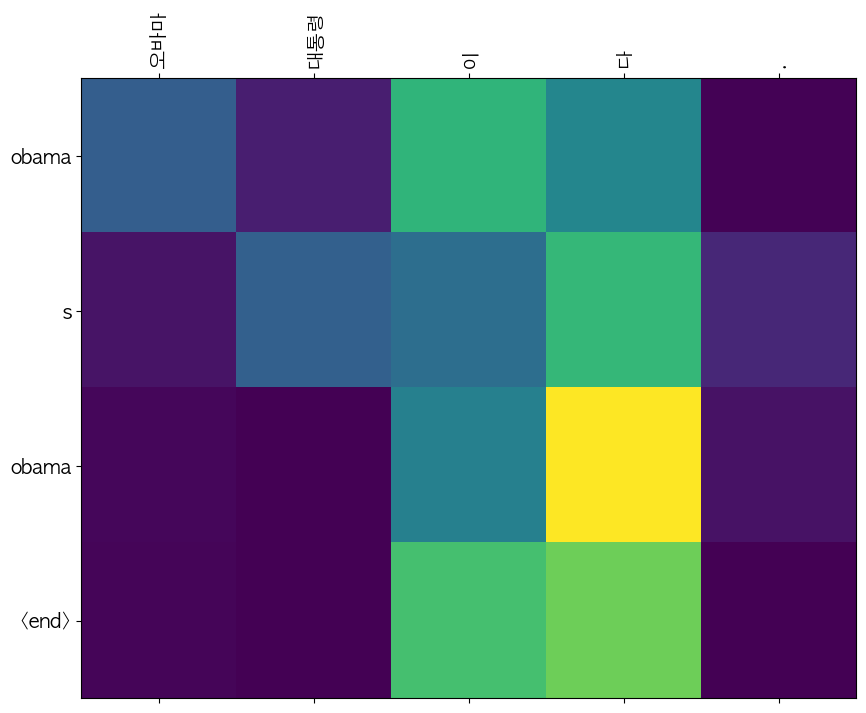


[Test K2] 시민들은 도시 속에 산다.


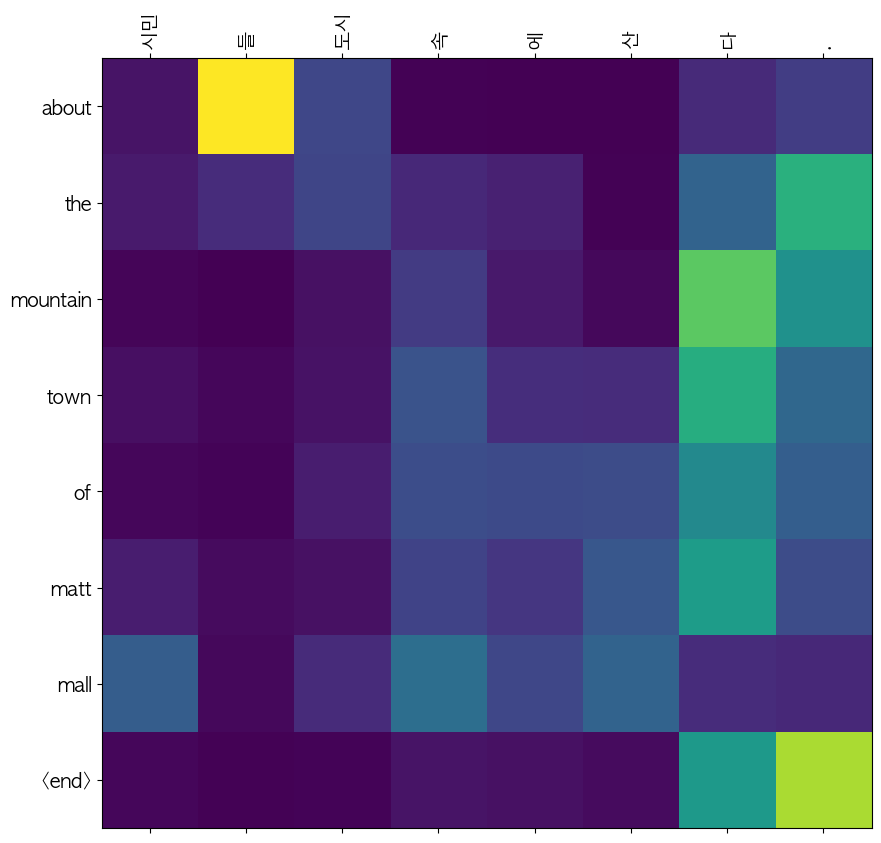


[Test K3] 커피는 필요 없다.


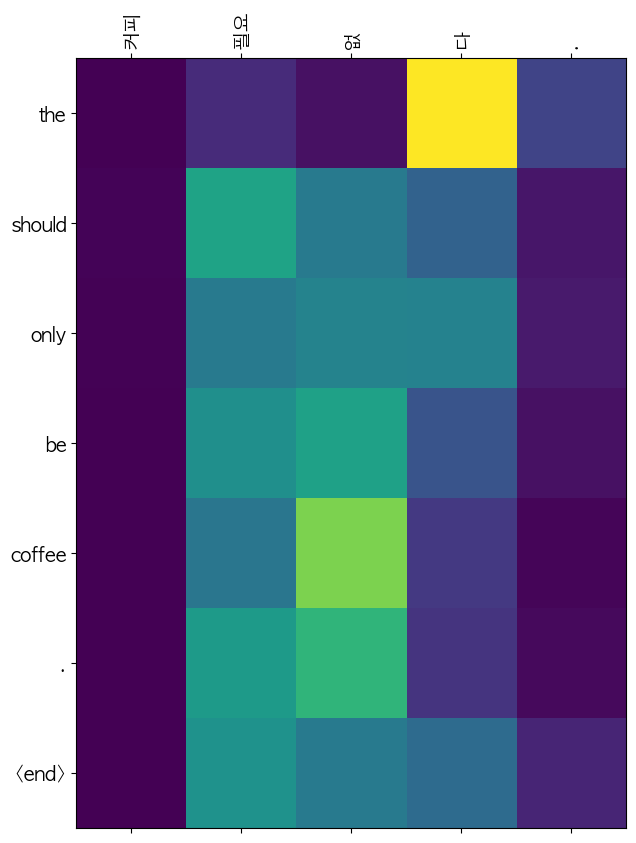


[Test K4] 일곱 명의 사망자가 발생했다.


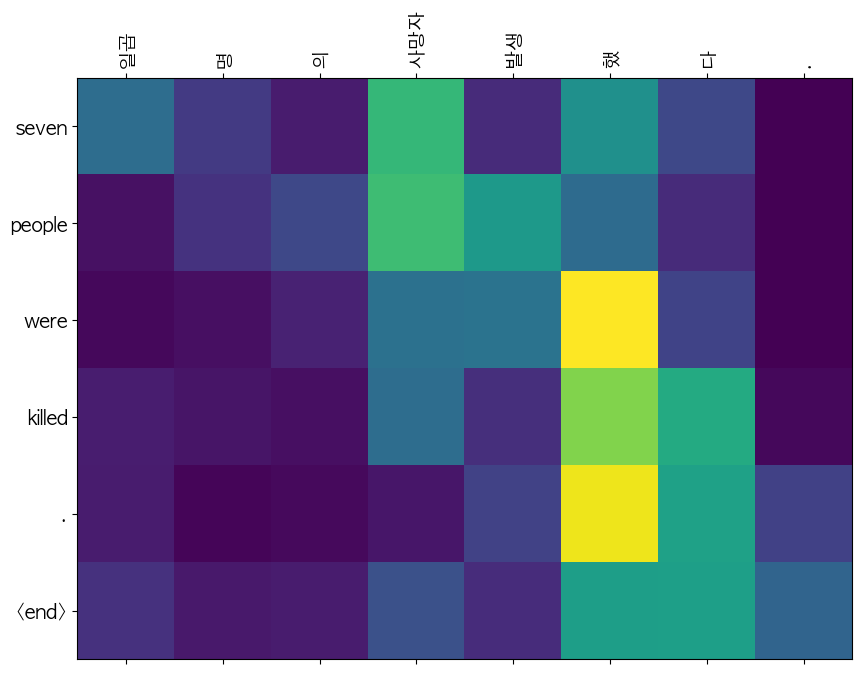

In [33]:
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

def plot_attention(attention, sentence, predicted_sentence):
    # attention: (trg_len, src_len) 형태의 텐서 또는 넘파이
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.matshow(attention, cmap='viridis')
    fontdict = {'fontsize': 14}
    # x축: 한국어 원문 (Input)
    ax.set_xticks(range(len(sentence)))
    ax.set_xticklabels(sentence, fontdict=fontdict, rotation=90)
    # y축: 영어 번역문 (Output)
    ax.set_yticks(range(len(predicted_sentence)))
    ax.set_yticklabels(predicted_sentence, fontdict=fontdict)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))
    plt.show()


def translate_and_visualize(sentences, model, ko_tokenizer, en_tokenizer):
    for i, s in enumerate(sentences):
        print(f"\n[Test K{i+1}] {s}")
        
        # 공통 추론 함수 호출
        pred_tokens, src_tokens, attention = translate_sentence(s, model, ko_tokenizer, en_tokenizer, CFG)
        
        # 어텐션 행렬 자르기 및 시각화
        attention_matrix = attention[:len(pred_tokens), :len(src_tokens)].cpu().detach().numpy()
        plot_attention(attention_matrix, src_tokens, pred_tokens)

# 실행!
translate_and_visualize(test_sentences, model, loaded_ko_tokenizer, loaded_en_tokenizer)


# 🚀 빔 서치(Beam Search) 알고리즘 심층 분석

본 프로젝트에서는 기존 `Greedy Search(탑욕적 탐색)`가 가진 근시안적 한계를 극복하기 위해 **빔 서치(Beam Search) 알고리즘**을 전격 도입하여 디코딩 추론(Inference) 로직을 고도화하였습니다.

## 1. 그리디 서치(Greedy Search)의 치명적 한계
기존의 그리디 방식은 매 스텝마다 오직 **가장 확률이 높은 1등 단어 단 1개**만을 선택합니다.
- **도돌이표 현상**: 앞서 단 한 번이라도 잘못된 경로(`obama s`)를 선택하면, 뒤집을 기회 없이 누적 문맥이 꼬여 끊임없이 같은 단어를 뱉거나 엉뚱한 결말로 빠지는 위험이 존재합니다.

## 2. 빔 서치(Beam Search)의 철학: "평행 우주 개척"
빔 서치는 나무(단기 확률)를 보지 않고 숲(문장 전체의 확률)을 봅니다. 
`beam_width = 3`일 때, 모델은 항상 **상위 3개의 우수 후보 문장(평행 우주)**을 동시에 살려두며 탐색을 진행합니다. 순간적으로 점수가 낮아 보이더라도, 나중에 엄청난 고득점 단어(`president`)가 붙을 포텐셜이 있다면 그 경로를 끝까지 탐색해 역전 우승을 만들어냅니다.

---

## 3. 핵심 동작 원리 (Step-by-Step)

### ⚙️ Step 1. 단어 예측과 채점 (`topk`)
디코더 네트워크는 20,000개 전체 단어장에 대한 활성화 값을 출력하고, 이를 `log_softmax`를 통해 확률(Score)로 변환합니다. 그중 **상적표 상위 3인방**을 추출합니다.

```python
# 1~3등 확률 점수와 단어 고유 ID 번호표(Token) 추출
topk_probs, topk_indices = log_probs.topk(beam_width)   
```

In [40]:
import torch
import torch.nn.functional as F

# =========================================================
# 1. 계산 함수: 번역 결과와 어텐션 맵을 한 번에 뽑아냄
# =========================================================
def translate_sentence_beam(sentence, model, ko_tokenizer, en_tokenizer, cfg, beam_width=3):
    """
    Greedy(탐욕적) 방식의 1등 쫓기 단점을 극복하고, 
    상위 K(beam_width)개의 평행 세계(후보)를 끝까지 비교하여 
    최적의 번역 루트를 찾아내는 빔 서치(Beam Search) 함수입니다.
    """
    # [준비 단계] 모델을 실전 모드(평가 모드)로 전환하고 기본 환경을 세팅합니다.
    model.eval()
    device = cfg['DEVICE']
    max_len = cfg['MAX_LEN']
    
    # [데이터 전처리] 입력된 한국어 문장을 정제, 토큰화(조사 분리 등)합니다.
    preprocessed = preprocess_korean(sentence, global_mecab)
    src_encoding = ko_tokenizer.encode(preprocessed)
    src_ids = src_encoding.ids       # [174, 281, ...] 같은 숫자 번호표
    src_tokens = src_encoding.tokens # ['현대', '자동차', ...] 형태소 단어들
    
    # [패딩 동기화] (중요) 훈련 환경과 100% 동일하게 길이를 64로 강제 세팅합니다.
    # 64칸이 안 되는 빈 공간은 모조리 [PAD] 번호로 채워 넣습니다.
    pad_id = ko_tokenizer.token_to_id("[PAD]")
    src_ids = src_ids[:max_len]
    src_ids = src_ids + [pad_id] * (max_len - len(src_ids))
    src_tensor = torch.tensor(src_ids).unsqueeze(0).to(device)
    
    # [특수 토큰 파악] 시작(<start>)과 끝(<end>)을 알리는 번호를 찾아놓습니다.
    bos_id = en_tokenizer.token_to_id("<start>")
    eos_id = en_tokenizer.token_to_id("<end>")
    
    # 실전에서는 미분이 필요 없으므로 연산 속도와 메모리를 아끼기 위해 grad를 끕니다.
    with torch.no_grad():
        # [인코딩] 한국어 문맥 압축 및 빈칸(PAD) 마스크 생성
        mask = (src_tensor != pad_id)
        encoder_outputs, hidden = model.encoder(src_tensor) # hidden: 인코더가 정리한 한국어 내용
        
        # 🌟 [빔 서치 초기화] 
        # beams 리스트 구조: [ (문장_기록_리스트, 누적_로그_점수, 디코더_히든상태, 어텐션맵_사진첩) ]
        # 최초에는 빈 문장에 <start> 토큰 하나만 덩그러니 있는 상태로 1개의 빔(길)이 시작됩니다.
        beams = [([bos_id], 0.0, hidden, [])]
        
        # 완벽히 <end>로 끝맺음된 우승 후보 문장들을 모아두는 졸업 앨범입니다.
        completed_beams = []
        
        # 최대 길이(64)만큼 한 단어씩 예측하며 뻗어나갑니다.
        for step in range(max_len):
            # 이번 스텝에서 만들어질 새로운 평행 세계(가지치기)를 담을 바구니
            new_beams = []
            
            # 현재 살아있는 K(빔 개수)개의 길을 하나씩 열어봅니다.
            for seq, score, h, att_history in beams:
                # 가지치기 1: 만약 이 길이 이미 <end>를 만나서 완주했다면?
                if seq[-1] == eos_id:
                    # 더 이상 단어를 찾지 말고 졸업 앨범으로 보낸 뒤 다음 길을 봅니다.
                    completed_beams.append((seq, score, h, att_history))
                    continue
                    
                # 디코더에 마지막으로 번역했던 단어를 미끼로 던져줍니다.
                input_tensor = torch.tensor([seq[-1]]).to(device)
                
                # 예측값과 새로운 히든 상태, 그리고 🌟어텐션 맵 구하기!
                prediction, new_h, attention = model.decoder(input_tensor, h, encoder_outputs, mask)
                
                # 확률(softmax)을 퍼센트로 구하는데, 빔 서치에서는 점수 계산을 쉽게 하려고
                # 곱하기 대신 더하기를 쓸 수 있는 로그(log)를 씌웁니다. (값은 항상 마이너스가 됨)
                log_probs = F.log_softmax(prediction, dim=1).squeeze(0)
                
                # 🌟 [빔 서치의 핵심] 가장 그럴싸한 상위 3등(beam_width)까지만 추려냅니다!
                topk_probs, topk_indices = log_probs.topk(beam_width)
                
                # 상위 3개의 단어 각각에 대해 새로운 세계(길)를 3갈래로 쪼개 만듭니다.
                for i in range(beam_width):
                    next_token = topk_indices[i].item() # 1~3등 단어 
                    next_score = score + topk_probs[i].item() # 과거 점수 + 이번 점수 누적
                    
                    # 배낭에 이번턴의 어텐션 맵 1장을 찰칵하고 찍어서 보관합니다.
                    new_att_history = att_history + [attention.unsqueeze(1)]
                    
                    # 뻗어나간 새로운 길 3개를 장바구니에 담습니다.
                    new_beams.append((seq + [next_token], next_score, new_h, new_att_history))
            
            # 가지치기 2: 만약 앨범(완주)에 등록된 문장이 우리가 목표한 K(빔)개를 꽉 채웠다면?
            # 굳이 더 탐색할 필요 없이 반복문을 조기 종료합니다!
            if len(completed_beams) >= beam_width:
                break
                
            # [랭킹 타임] 1회전이 끝났습니다. 새로 뻗어나간 길 + 기둥 길을 싹 다 모읍니다.
            all_beams = new_beams + completed_beams
            
            # 🌟 [공정한 심사] 단순 누적 점수는 문장이 길어질수록 계속 깎여서 불리해집니다 (로그라서).
            # 그래서 '문장 길이의 0.7제곱'으로 나눠서 긴 문장이 손해보지 않게 패널티 점수를 줍니다 (Length Penalty)
            all_beams = sorted(all_beams, key=lambda x: x[1] / (len(x[0]) ** 0.7), reverse=True)
            
            # 수십 개의 길 중에서 딱 냉정하게 1등부터 3등(K번)까지만 살리고 나무를 쳐버립니다!
            beams = all_beams[:beam_width]

        # [최후의 승자 결정] 끝까지 살아남은 가장 확률이 높은 1위 빔(Beam)의 데이터를 꺼냅니다.
        best_beam = beams[0] if len(beams) > 0 else ([bos_id], 0.0, hidden, [])
        best_seq = best_beam[0]          # 1등이 완성한 영어 번호표 리스트
        best_attentions = best_beam[3]   # 1등이 걸으면서 찰칵찰칵 찍은 어텐션 사진첩
    
    # [후처리] 숫자 번호표(ID)를 사람이 읽을 수 있는 알파벳(Token)으로 바꿉니다.
    pred_tokens = []
    for token_id in best_seq:
        token = en_tokenizer.id_to_token(token_id)
        if token == "<end>":
            pred_tokens.append("<end>")
            break # 끝을 만나면 탈출
        if token not in ["[PAD]", "<start>", "[UNK]"]:
            pred_tokens.append(token) # 찌꺼기가 아닌 순수 영단어만 담기
            
    # [사진첩 합치기] 낱장으로 담겨있던 어텐션 맵 배열들을 하나의 통짜 그림 텐서로 조립합니다.
    if best_attentions:
        final_attention = torch.cat(best_attentions, dim=1) 
    else:
        # 혹시나 탐색 실패 방어용 투명 사진첩
        final_attention = torch.zeros(1, 1, len(src_tokens)) 
        
    # 최종 결과물 3종 세트를 반환하여 시각화 함수에 쥐어줍니다.
    return pred_tokens, src_tokens, final_attention[0]


### 빔 서치(Beam Search) 적용 결과 (단어망 3개 동시 탐색) ###
K) 오바마는 대통령이다.
E) i obama s president obama . <end>

K) 시민들은 도시 속에 산다.
E) people were in the town of cities ? <end> <end>

K) 커피는 필요 없다.
E) the should only be coffee . <end> <end>

K) 일곱 명의 사망자가 발생했다.
E) seven people were killed . <end> <end>


### 빔 서치(Beam Search) 어텐션 맵 시각화 ###


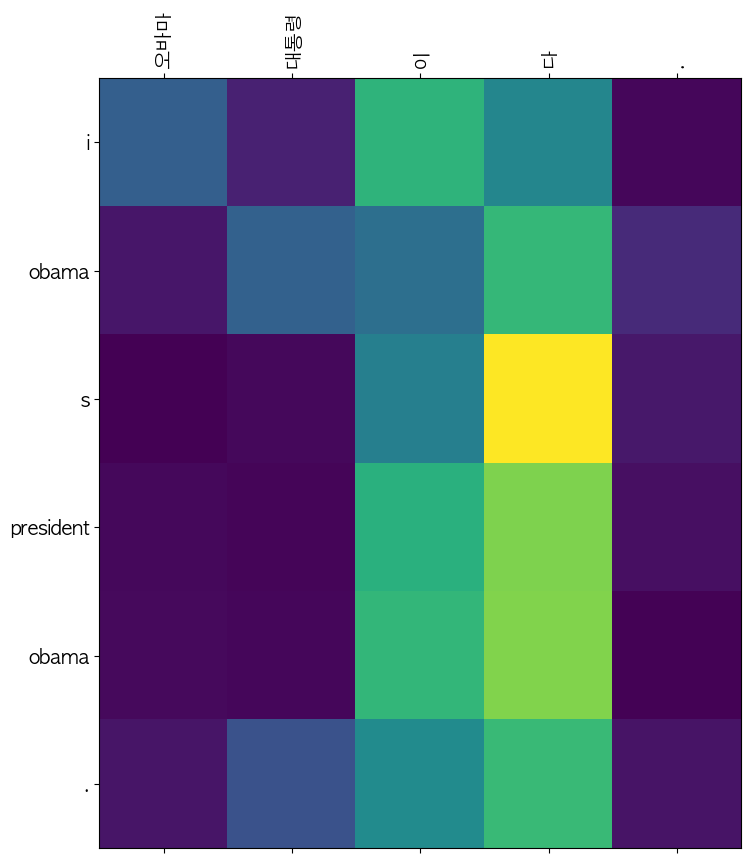

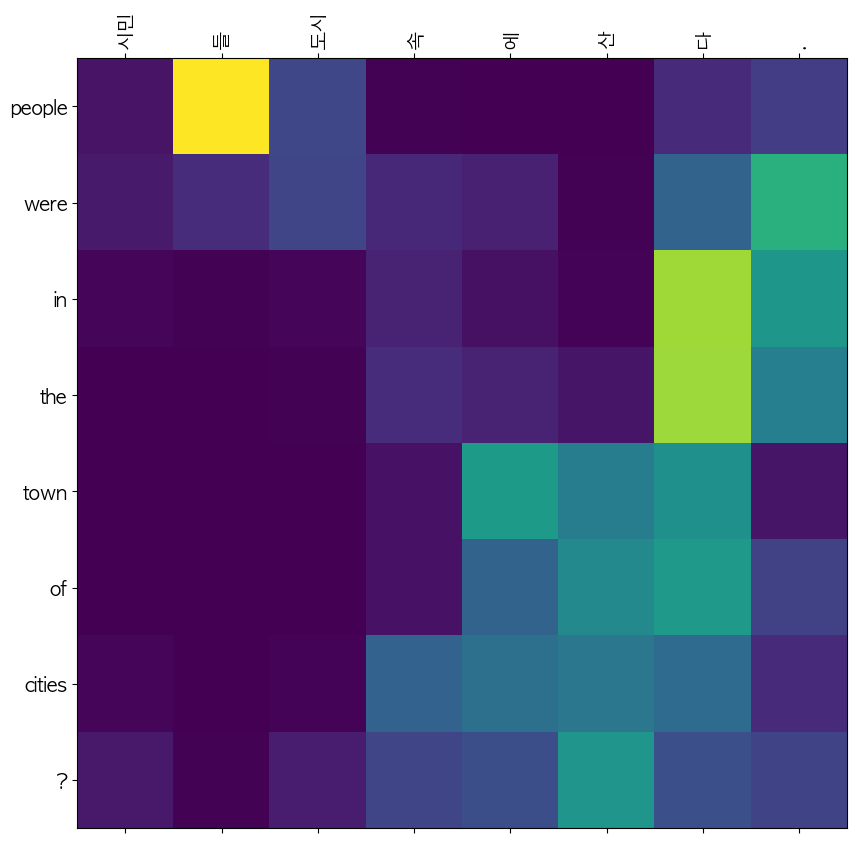

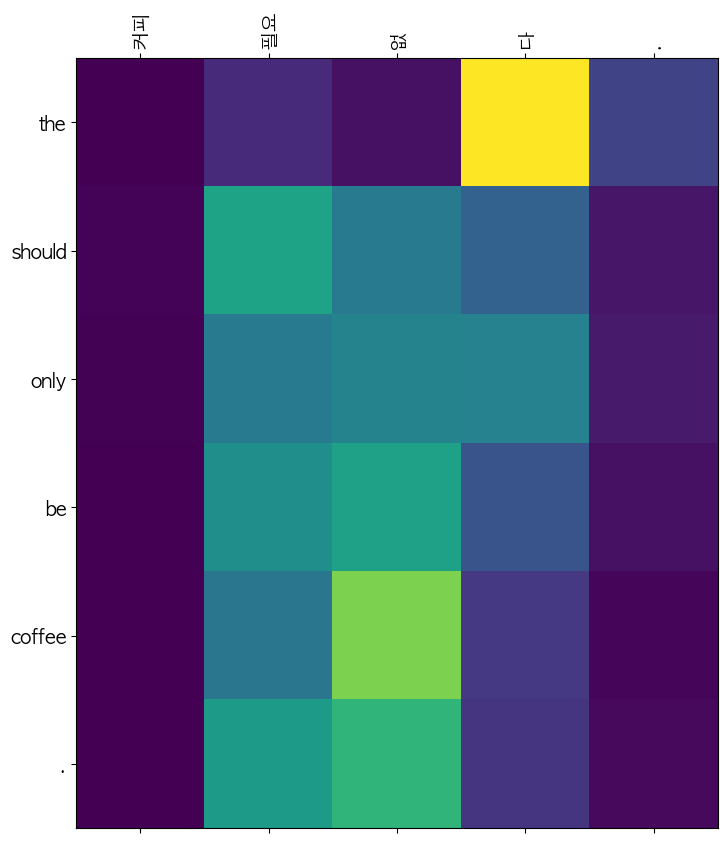

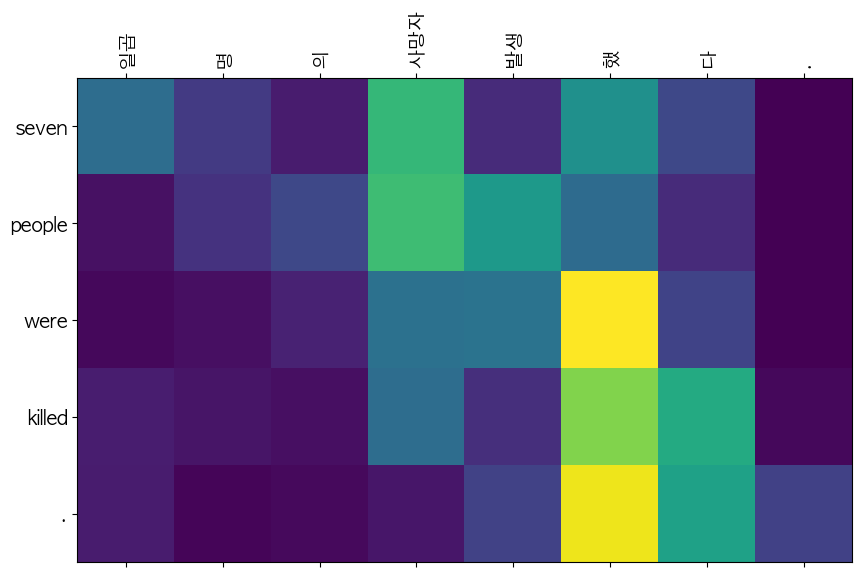

In [41]:
# =========================================================
# 2. 실행 및 출력: 텍스트 먼저, 어텐션 맵은 나중에!
# =========================================================
print("### 빔 서치(Beam Search) 적용 결과 (단어망 3개 동시 탐색) ###")

# 출력된 결과(그림용)를 담아둘 보관함 준비 (어텐션 맵을 한 번에 모아서 띄우기 위함)
beam_results = []

# [Phase 1. 번역 텍스트만 쭉 출력]
for s in test_sentences:
    # 빔 서치를 돌려서 1등 문장의 영단어, 한국어단어, 어텐션사진을 싹 다 받아옵니다.
    pred_tokens, src_tokens, attention = translate_sentence_beam(
        s, loaded_model, loaded_ko_tokenizer, loaded_en_tokenizer, CFG, beam_width=3
    )
    
    # 출력 결과를 이쁘게 문자열로 꿰어 맞춥니다.
    translation = " ".join(pred_tokens) + " <end>" 
        
    print(f"K) {s}")
    print(f"E) {translation}\n")
    
    # 지금 바로 그림을 안 그리고, 일단 시각화용 재료함(beam_results)에 얌전히 던져 넣습니다.
    beam_results.append((s, src_tokens, pred_tokens, attention))


# [Phase 2. 저장해둔 어텐션 맵들을 이어서 연달아 시각화]
print("\n" + "="*50)
print("### 빔 서치(Beam Search) 어텐션 맵 시각화 ###")
for s, src_tokens, pred_tokens, attention in beam_results:
    # 그림 그리기용 전처리: y축 라벨에 굳이 필요없는 "<end>" 기호는 깔끔하게 떼버립니다.
    display_pred = [t for t in pred_tokens if t != "<end>"]
    
    # 텐서(gpu) 형태의 어텐션 맵을 시각화를 위해 순수 숫자(cpu, numpy) 보드로 꺼내옵니다.
    attention_matrix = attention[:len(display_pred), :len(src_tokens)].cpu().detach().numpy()
    
    # 미리 만들어두신 화려한 히트맵(matplotlib) 함수를 쏴서 그림을 그립니다!
    plot_attention(attention_matrix, src_tokens, display_pred)

# 회고

- 이번 프로젝트를 하면서 느낀점, 배운점
  - seq2seq 구조, attention 메카니즘을 소스 코드 레벨에서 확인 할수 있어서 좋았습니다.
  - attention map을 활용해 어느 부분이 문제가 되는지 파악알수 있었습니다.
  - 조사(은, 는, 이, 가)에 과도한 집착 어텐션 스코어를 보면 모델이 핵심 명사(커피, 일곱, 대통령)보다 조사나 어미에 집중할 때 엉뚱한 단어를 마구잡이로 지어내는 현상이 뚜렷합니다. 한국어의 조사가 영어의 어떤 전치사/관사와 매핑되어야 하는지 데이터가 부족하여 혼란을 겪고 있습니다.
- 이번 프로젝트에서 잘 했다고 생각이 드는 점.
  - 이 프로젝트 소스를 구조화 할수 있어서 좋았습니다.
  - CFG를 따로 만들어서, configuration을 따로 관리했고, 각각의 configuration을 조정합으로서 관리하기가 쉬었습니다.
  - 가장 오차율이 적은 모델 데이타를 저장해서, best한 모델을 만들었습니다.
  - 가중치 초기화를 해주었습니다.
  - Teacher forcing을 80퍼센트로 제한해서 실직적으로 train, valiation하는것과 같은 효과를 만들었습니다.
  - Teacher forcing을 처음에 100퍼센트 했더니, 오차율(0.8이하)은 낮은데, 추론시 4개의 문장중 2개만 어느정도 번역에 성공했는데, 그것도 완벽한 번역은 아니었습니다.
- 이번 프로젝트에서 느낀 문제점.
  - Teacher forcing을 80퍼센트로 제한해서 아무레도 Teacher forcing 100 퍼센트보다 오차율이크다.
  - 오차율을 만회하기 위해서 Epoch 횟수를 늘려서 너무많은 훈련시간이 소비되었습니다.
  - 모델을 돌려놓았는데, 컴퓨터가 슬립에 빠져서, 훈련시간이 많이 지나도 에포크가 크게 늘어나지 않아다..반드시 `caffeinate -i` 를 해서 슬립에 들어가지 않도록 해야합니다.
  - 한국어 형태소 분리해서 번역은 조사때문에 특별히 더 신경을 써야합니다.
  - 뉴스 문장이 아닌, 일상적인 문장에서는 번역이 제대로 되지 않았습니다.(데이터 말뭉치의 처참한 편식)
  - AI의 도움을 크게 받아서 빔 서치를 적용해도 약간의 개선이 있을뿐, 크게 개선이 되잖않았습니다.
- 다음에는 이렇게 해야겠다 생각한 점.
  - 좀더 다양하게 하이퍼 파라메터 튜닝을 해야겠습니다(Grid search)
  - 좀더 추론에서 빨리 왜 번역이 제대로 어텐션 맵을 안되는지 파악을 했어야했는데 너무 트레이닝 점수에만 매달렸습니다. 객관적인 분석이 먼저 이루어져야하겠습니다.